<a href="https://colab.research.google.com/github/Alee-M/Taking_a_Swing_at_Probability_Neural_Networks_Comparison/blob/main/BNN_Ensemble_Comparison_SOPA_Final_Updated_Data_V2_github.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Import Packages and Data

In [ ]:
#Connect to Google Drive
from google.colab import drive
#mount drive

Mounted at /content/drive


In [ ]:
#Install correct verison of tensorflow
!pip uninstall tensorflow-probability
!pip install -q "tensorflow-probability[tf]"

Found existing installation: tensorflow-probability 0.25.0
Uninstalling tensorflow-probability-0.25.0:
  Would remove:
    /usr/local/lib/python3.12/dist-packages/tensorflow_probability-0.25.0.dist-info/*
    /usr/local/lib/python3.12/dist-packages/tensorflow_probability/*
Proceed (Y/n)? Y
  Successfully uninstalled tensorflow-probability-0.25.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 67.5 MB/s eta 0:00:00


In [ ]:
#Import necessary packages and functions
import tensorflow as tf
import tensorflow_probability as tfp
import tf_keras
from tf_keras import layers

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from keras.metrics import Accuracy
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

from keras import backend as K
from scipy.stats import pearsonr

import time
import math
import random

from keras import optimizers
from keras.layers import Input
from keras.models import Model

import seaborn as sns
import scipy.stats as stats

from tf_keras.models import Model
from tf_keras.models import load_model

import string
import matplotlib.ticker as ticker

In [ ]:
#Verify tensorflow probability version
print(tfp.__version__)

0.25.0


In [ ]:
# Set directory to load files

dir = 'set_dir'


#### Demonstration of relationship between All-Star Break SO/PA and end of season SO/PA.

Training Data Correlation Coefficent:  0.9616371557978066


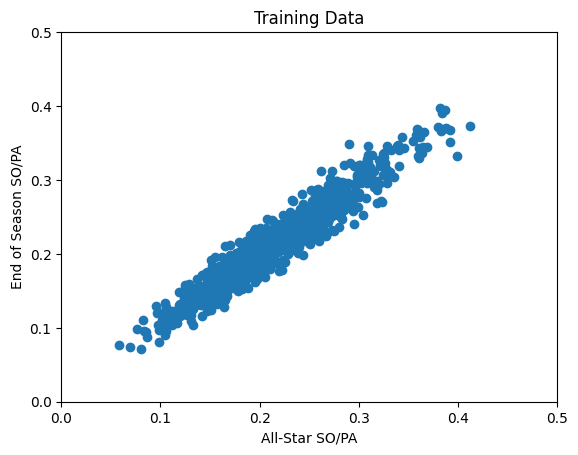

In [ ]:
#Loading in data
#One npz file for training, another for testing
f = dir + "Baseball_Full_Train2.npz"
npzfile = np.load(f)
#Subsetting to isolate inputs and outputs
xTrain = npzfile['xTrain']
yTrain = npzfile['yTrain']
#Isolating strikeout rate (dataframe includes player ID and SO/PA)
yTrain = yTrain[:,1]

#Calculating strikeout rate with SO and PA metrics
sopaTrain = xTrain[:, 1] / xTrain[:,2]

#Plotting Training Data: SO/PA at All-Star Break vs End of Season to demonstrate relationship
plt.scatter(sopaTrain, yTrain)
plt.title('Training Data')
plt.xlabel('All-Star SO/PA')
plt.ylabel('End of Season SO/PA')
plt.xlim(0,.5)
plt.ylim(0,.5)

#Correlation coefficient
train_r_value = np.corrcoef(sopaTrain, yTrain)[0, 1]
print("Training Data Correlation Coefficent: ",train_r_value)

Training Data Correlation Coefficent:  0.9605821517300708


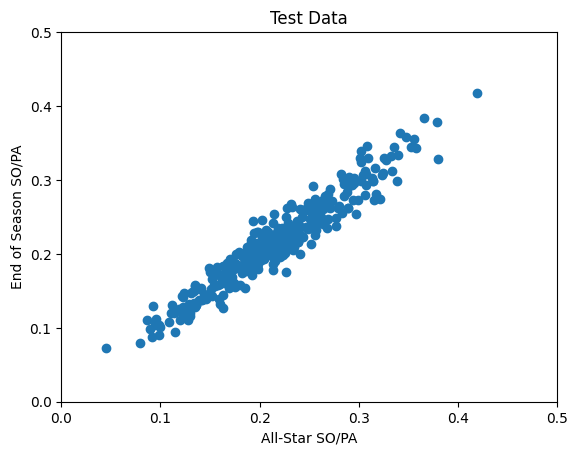

In [ ]:
#Importing testing dataset
f = dir + "Baseball_Full_Test2.npz"
npzfile = np.load(f)
xTest = npzfile['xTest']
yTest = npzfile['yTest']
#Isolating strikeout rate (dataframe includes player ID and SO/PA)
yTest = yTest[:,1]

#Calculating strikeout rate with SO and PA metrics
sopaTest = xTest[:, 1] / xTest[:,2]

#Plotting Testing Data: SO/PA at All-Star Break vs End of Season to demonstrate relationship
plt.scatter(sopaTest, yTest)
plt.title('Test Data')
plt.xlabel('All-Star SO/PA')
plt.ylabel('End of Season SO/PA')
plt.xlim(0,.5)
plt.ylim(0,.5)

#Correlation coefficient
test_r_value = np.corrcoef(sopaTest, yTest)[0, 1]
print("Training Data Correlation Coefficent: ",test_r_value)

In [ ]:
#Size of Test and Training Data
print("X Train: ",len(sopaTrain))
print("X Test: ",len(sopaTest))
print("Y Train: ",len(yTrain))
print("Y Test: ",len(yTest))

X Train:  1016
X Test:  339
Y Train:  1016
Y Test:  339


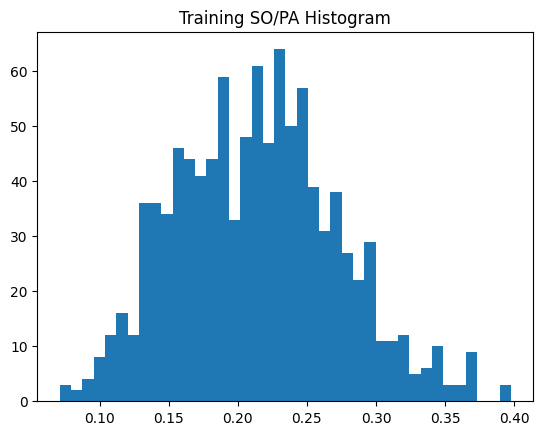

In [ ]:
#Histogram of Training data (End of Season SO/PA)
plt.hist(yTrain, bins=40)
plt.title("Training SO/PA Histogram")
plt.show()

In [ ]:
#Calculating summary statistics for each training/testing data subset
TrainX_Summary = {
'Min': [round(min(sopaTrain),3)],
'Max': [round(max(sopaTrain),3)],
'Mean': [round(np.mean(sopaTrain),3)],
'Median': [round(np.median(sopaTrain),3)],
'St Dev': [round(np.std(sopaTrain),3)] }
TrainX_Summary = pd.DataFrame(TrainX_Summary,index=(['Train_X']))

TrainX_Summary


,Min,Max,Mean,Median,St Dev
Train_X,0.058,0.412,0.215,0.214,0.06


In [ ]:
TrainY_Summary = {
'Min': [round(min(yTrain),3)],
'Max': [round(max(yTrain),3)],
'Mean': [round(np.mean(yTrain),3)],
'Median': [round(np.median(yTrain),3)],
'St Dev': [round(np.std(yTrain),3)] }
TrainY_Summary = pd.DataFrame(TrainY_Summary,index=(['Train_Y']))

TrainY_Summary

,Min,Max,Mean,Median,St Dev
Train_Y,0.071,0.398,0.214,0.214,0.059


In [ ]:
TestX_Summary = {
'Min': [round(min(sopaTest),3)],
'Max': [round(max(sopaTest),3)],
'Mean': [round(np.mean(sopaTest),3)],
'Median': [round(np.median(sopaTest),3)],
'St Dev': [round(np.std(sopaTest),3)] }
TestX_Summary = pd.DataFrame(TestX_Summary,index=(['Test_X']))

TestX_Summary

,Min,Max,Mean,Median,St Dev
Test_X,0.045,0.419,0.216,0.213,0.062


In [ ]:
TestY_Summary = {
'Min': [round(min(yTest),3)],
'Max': [round(max(yTest),3)],
'Mean': [round(np.mean(yTest),3)],
'Median': [round(np.median(yTest),3)],
'St Dev': [round(np.std(yTest),3)] }
TestY_Summary = pd.DataFrame(TestY_Summary,index=(['Test_Y']))

TestY_Summary

,Min,Max,Mean,Median,St Dev
Test_Y,0.073,0.418,0.215,0.211,0.061


In [ ]:
#Table with all summary stats
All_Summary_Stats = pd.concat([TrainX_Summary, TrainY_Summary, TestX_Summary, TestY_Summary])
All_Summary_Stats

,Min,Max,Mean,Median,St Dev
Train_X,0.058,0.412,0.215,0.214,0.060
Train_Y,0.071,0.398,0.214,0.214,0.059
Test_X,0.045,0.419,0.216,0.213,0.062
Test_Y,0.073,0.418,0.215,0.211,0.061


###Develop Methods to Construct and Evaluate Bayesian Neural Networks


In [ ]:
#Methods to calculate aleatoric and epistemic uncertainty based on formulas from study by Valdenegro-Toro and Mori


#Aleatoric uncertainty is defined as the mean of variances
def getAleatoric( variances ):

    #initialize empty list to store aleatoric uncertainty for each player
    aleatoric = []

    n = len( variances[0] ) # number of players
    nEnsemble = len( variances ) # total number predictions made (number of output distributions)

    for i in range(n):
        var = []
        for j in range(nEnsemble):
            var.append(variances[j][i]) #j is index of output distribution (variance of distribution), i represents player
        aleatoric.append( np.mean(var) ) #take mean of variances for each player and add to aleatoric list

    return aleatoric

#Epistemic uncertainty is defined as the variance of means
def getEpistemic( means ):

    #initialize empty list to store epistemic uncertainty for each player
    epistemic = []

    n = len( means[0] ) # number of players
    nEnsemble = len( means ) # total number predictions made (number of output distributions)

    for i in range(n):
        mns = []
        for j in range(nEnsemble):
            mns.append(means[j][i]) #j is index of output distribution (mean of distribution), i represents player
        m = np.mean( mns ) #average of means
        mns = np.array(mns)
        diffs = mns**2 - m**2 #For each player, calculate variance (difference between the mean of each distribution and the average of means)
        epistemic.append( np.mean(diffs) ) #take average variance of means

    return epistemic

In [ ]:
# Loss Function - negative log-likelihood
def nll(y_true, y_pred):
    return -y_pred.log_prob(y_true)

In [ ]:
tfd = tfp.distributions

# Posterior factory with the required signature (kernel_size, bias_size=0, dtype=None)
def posterior_mean_field(kernel_size, bias_size=0, dtype=None):
    n = kernel_size + bias_size #total number of distributions generated
    c = np.log(np.expm1(1.0))  # small stable init
    return tf_keras.Sequential([
        tfp.layers.VariableLayer(2 * n, dtype=dtype),
        tfp.layers.DistributionLambda(
            lambda t: tfd.Independent(
                tfd.Normal(loc=t[..., :n],
                           scale=1e-5 + tf.nn.softplus(c + t[..., n:])),
                reinterpreted_batch_ndims=1))
    ])

# fixed standard normal prior (non-trainable)
def prior_standard_normal(kernel_size, bias_size=0, dtype=None):
    n = kernel_size + bias_size #total number of distributions generated
    return tf_keras.Sequential([
        tfp.layers.DistributionLambda(
            lambda _: tfd.Independent(
                tfd.Normal(loc=tf.zeros(n, dtype=dtype), scale=1),
                reinterpreted_batch_ndims=1))
    ])


Defining a small BNN with the following layers
* input = All-Star Break SO/PA
* hidden layer 1 with 12 nodes
* hidden layer 2 with 6 nodes
* ouput = predicted end of season SO/PA (mean and variance)

Weight priors are standard normal, N(0,1), and posterior weight distributions are a learned normal.

Predictions are also normal distributions.

A few special modifications to ensure the BNN trains well
* kl_weight is larger than the typically used value of 1/len(xTrain) - limits how much the weight posteriors differ from the weight priors
* train for 8000 epochs - BNNs can take a long time to find the optimal results because they are trying to learn 3 things at the same time (how to map from inputs to outputs, epistemic uncertainty, aleatoric uncertainty)
* we also add a small number to the variance predictions to address rounding issues where we end up with zero standard deviation during training epochs - the line: scale = tf.nn.softplus(raw_scale) + 1e-3

In [ ]:
#Creating model with the above specifications
bnn = tf_keras.Sequential([
        #Input layer
        tf_keras.layers.Input(shape=(1,)),

        #First hidden layer
        tfp.layers.DenseVariational(
            units=12,
            make_posterior_fn=posterior_mean_field,#Posteriors
            make_prior_fn=prior_standard_normal,#Priors
            kl_weight=1/sopaTrain.shape[0],
            activation='relu'
        ),
        #Second hidden layer
        tfp.layers.DenseVariational(
            units=6,
            make_posterior_fn=posterior_mean_field,#Posteriors
            make_prior_fn=prior_standard_normal,#Priors
            kl_weight=1/sopaTrain.shape[0],
            activation='relu'
        ),
        #Output layer
        tf_keras.layers.Dense(units=2),
        tfp.layers.DistributionLambda( lambda t: tfd.Independent(
            tfd.Normal(loc=t[..., 0],
            scale=1e-5 + tf.nn.softplus(t[..., 1])),
            reinterpreted_batch_ndims=1) ) #Output is a normal distribution
    ])

#Compile model with nll loss function and MAE metric to monitor accuracy throughout training
bnn.compile(loss=nll, optimizer=tf_keras.optimizers.Adam(learning_rate=1e-3), metrics=['MAE'])

In [ ]:
#Architecture of Model
bnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_variational (DenseVa  (None, 12)                48        
 riational)                                                      
                                                                 
 dense_variational_1 (Dense  (None, 6)                 156       
 Variational)                                                    
                                                                 
 dense (Dense)               (None, 2)                 14        
                                                                 
 distribution_lambda (Distr  ((None,),                 0         
 ibutionLambda)               (None,))                           
                                                                 
Total params: 218 (872.00 Byte)
Trainable params: 218 (872.00 Byte)
Non-trainable params: 0 (0.00 Byte)
__________________

In [ ]:
#Ratio of parameters in model to training size
#Total parameters - 218
#Validation -> 0.1 * 1016 = 101.6 (101)
#Training set size -> 1016 - 101 = 915
bnn_ratio = 218/915
print(f"BNN ratio: {bnn_ratio:.6f}")

BNN ratio: 0.238251


In [ ]:
#fit model with training data, 10% of training data used for validation
h = bnn.fit(sopaTrain, yTrain, batch_size=64, epochs=8000, validation_split = 0.1)

Streaming output truncated to the last 5000 lines.
15/15 [==============================] - 0s 6ms/step - loss: 120.3816 - MAE: 2.6095 - val_loss: 109.8211 - val_MAE: 2.6601
Epoch 2734/8000
15/15 [==============================] - 0s 6ms/step - loss: 138.8421 - MAE: 2.9423 - val_loss: 80.9615 - val_MAE: 1.1490
Epoch 2735/8000
15/15 [==============================] - 0s 6ms/step - loss: 106.2167 - MAE: 1.9616 - val_loss: 87.1726 - val_MAE: 1.6224
Epoch 2736/8000
15/15 [==============================] - 0s 6ms/step - loss: 115.5442 - MAE: 2.2526 - val_loss: 162.4865 - val_MAE: 6.3145
Epoch 2737/8000
15/15 [==============================] - 0s 7ms/step - loss: 113.2533 - MAE: 2.1362 - val_loss: 2690.2820 - val_MAE: 1.6321
Epoch 2738/8000
15/15 [==============================] - 0s 7ms/step - loss: 123.2189 - MAE: 2.5231 - val_loss: 101.3528 - val_MAE: 2.8470
Epoch 2739/8000
15/15 [==============================] - 0s 7ms/step - loss: 111.0260 - MAE: 2.0591 - val_loss: 126.9117 - val_MAE: 

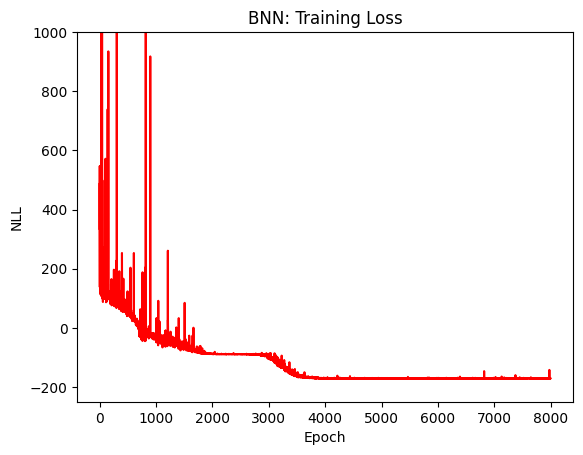

In [ ]:
#Visualize loss over training epochs
train_loss = h.history['loss']  # Training loss per epoch
plt.plot(train_loss, color = 'red')
plt.title('BNN: Training Loss')
plt.ylabel('NLL')
plt.xlabel('Epoch')
plt.ylim(-250,1000)

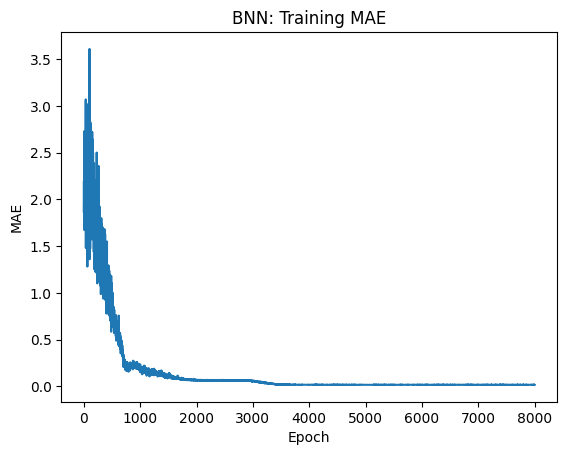

In [ ]:
#Visualize MAE over training epochs
train_accuracy = h.history['MAE']  # MAE per epoch
plt.plot(train_accuracy)
plt.title('BNN: Training MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')

#### Save the BNN for later use

In [ ]:
#Save weights
path = dir + 'bnn_so_pa.weights.h5'
bnn.save_weights(path)

/usr/local/lib/python3.12/dist-packages/tf_keras/src/saving/serialization_lib.py:159: UserWarning: The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized:             lambda _: tfd.Independent(
                tfd.Normal(loc=tf.zeros(n, dtype=dtype), scale=1),
                reinterpreted_batch_ndims=1))

  config_arr = [serialize_keras_object(x) for x in obj]


In [ ]:
#Re-load weights
path = dir + 'bnn_so_pa.weights.h5'
bnn.load_weights(path)

/usr/local/lib/python3.12/dist-packages/tf_keras/src/saving/serialization_lib.py:159: UserWarning: The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized:             lambda _: tfd.Independent(
                tfd.Normal(loc=tf.zeros(n, dtype=dtype), scale=1),
                reinterpreted_batch_ndims=1))

  config_arr = [serialize_keras_object(x) for x in obj]


###Evaluate Bayesian Neural Network

Calculate Aleatoric and Epistemic Uncertainty for BNN

In [ ]:
# Obtain 1000 distributions for each player in the test data
n = 1000
#Creating empty lists to fill in
means_bnn = np.zeros( shape=(n,sopaTest.shape[0]) )
variances_bnn = np.zeros( shape=(n,sopaTest.shape[0]) )

#Loop through 1000 times
for i in range(n):
    #Get an output distribution for each player
    predictions_bnn = bnn(sopaTest)
    #Extract the mean from the distributions and add to lists
    means_bnn[i,:] = np.array( predictions_bnn.mean())
    #Extract the variance from the distributions and add to lists
    variances_bnn[i,:] = np.array( predictions_bnn.variance())

means_bnn.shape, variances_bnn.shape

((1000, 339), (1000, 339))

In [ ]:
# Aleatoric Uncertainty
aleatoric_bnn=getAleatoric(variances_bnn)
#transform into numpy array
aleatoric_bnn = np.array(aleatoric_bnn)

# Epsitemic Uncertainty
epistemic_bnn = getEpistemic(means_bnn)
#transform into numpy array
epistemic_bnn = np.array(epistemic_bnn)

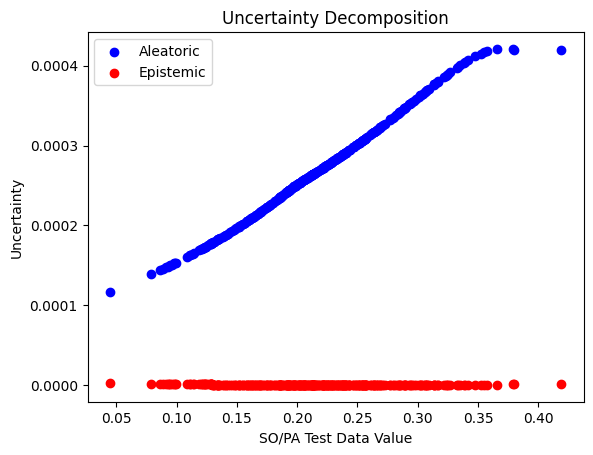

In [ ]:
#Visualizing aleatoric and epistemic uncertainty vs actual test values
plt.scatter(sopaTest, aleatoric_bnn, label='Aleatoric', color='blue')
plt.scatter(sopaTest, epistemic_bnn, label='Epistemic', color='red')
plt.title('Uncertainty Decomposition')
plt.xlabel('SO/PA Test Data Value')
plt.ylabel('Uncertainty')
plt.legend()

MAE of Final Predictions

In [ ]:
# Final prediction is the average of 1000 predictions for each player
predictions_bnn = np.mean( means_bnn, axis=0 )

In [ ]:
#MAE of test data
mean_absolute_error( predictions_bnn, yTest )

0.013606180655156026

In [ ]:
#MAE of training data
mean_absolute_error( bnn.predict(sopaTrain), yTrain )

32/32 [==============================] - 1s 1ms/step


0.018288769718542573

#### How do BNN predictions compare to actual SO/PA?

Text(0, 0.5, 'Number of Occurences')

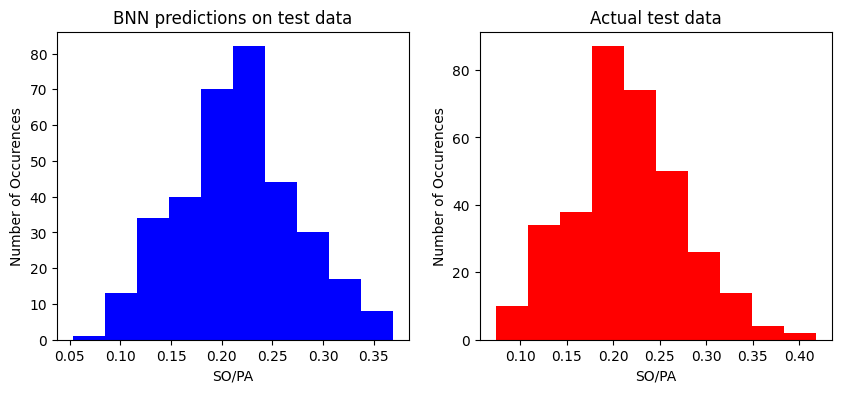

In [ ]:
#Histogram of predictions and actual data
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Predictions (left)
axs[0].hist(predictions_bnn, color='blue')
axs[0].set_title('BNN predictions on test data')
axs[0].set_xlabel('SO/PA')
axs[0].set_ylabel('Number of Occurences')

# Actual data (right)
axs[1].hist(yTest, color='red')
axs[1].set_title('Actual test data')
axs[1].set_xlabel('SO/PA')
axs[1].set_ylabel('Number of Occurences')

(0.0, 0.5)

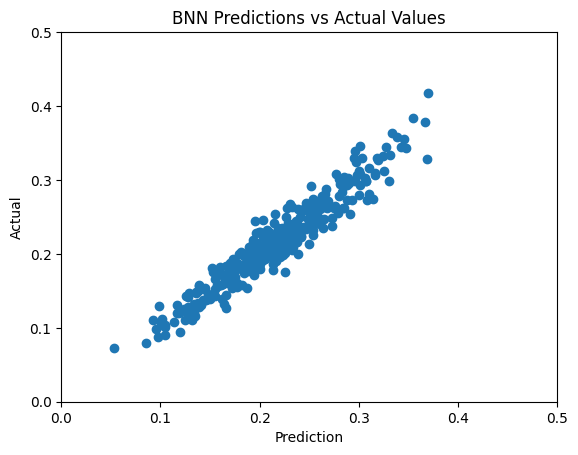

In [ ]:
#Scatterplot of actual values vs predictions
plt.scatter(predictions_bnn, yTest)
plt.title('BNN Predictions vs Actual Values')
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.xlim(0,.5)
plt.ylim(0,.5)

#### Predition Intervals

It's fairly common to see this method:
* total uncertainty = epistemic + aleatoric (supported by the law of total variance)
* prediction interval = prediction +/- 1.96*sqrt (total uncertainty)

The first step is valid. The second step assumes the predictive uncertainty follows a normal distribution, which is not always true.

As a result, the percentile-based method tends to overestimate and create too large uncertainty intervals.

We've found better success with the following percentile approach

Percentile Method
* We have 1000 predictions for each player in the test set
* Each of those 1000 predictions is a Normal distribution (mean/variance)
* Conduct a Monte Carlo approach - take samples from each of the 1000 distributions and build up a final prediction distribution
* Find where 95% of the predictions lie and use that as our 95% prediction interval

In [ ]:
#Percentile Method
#number of players in our test data
n = 339

# array to hold our results
#Size is 10000 -> 10 samples from each of the 1000 distributions for each player
samples_bnn = np.zeros( shape=(10000,n) )

# loop over every player in the test data
for i in range(n):

  #empty list to store samples
  s = []

  # status update
  if ( i == 100 ): print("Working on player 100 of", n)
  if ( i == 200 ): print("Working on player 200 of", n)
  if ( i == 300 ): print("Working on player 300 of", n)

  # we created 1000 predictions for each player so we loop 1000 times
  for j in range(1000):

    # what is the jth prediction for this player (i)?
    mean_bnn = means_bnn[j, i]
    variance_bnn = variances_bnn[j, i]

    # we have variance, but need standard deviation
    sd = np.sqrt(variance_bnn)

    # take samples from this predicted normal distribution
    # we'll use 10 - the more you take the better the estimate, but the slower the loop
    sample_bnn = np.random.normal(loc=mean_bnn, scale=sd, size=10)
    s.extend(sample_bnn)

  # before moving on to the next player, add the samples to our array
  samples_bnn[:,i] = s

Working on player 100 of 339
Working on player 200 of 339
Working on player 300 of 339


In [ ]:
#Percentile Intervals for all players

#create empty lists to store upper and lower bounds
plow_bnn = []
phigh_bnn = []

#initialize counter at 0
count = 0

#for each player, calculate the 2.5th and 97.5th percentile
for i in range(339):

  plow_bnn.append( np.percentile(samples_bnn[:,i], 2.5) )
  phigh_bnn.append( np.percentile(samples_bnn[:,i], 97.5) )

  #if the interval contains the acutal test value, increase the counter
  if ( (yTest[i] >= plow_bnn[i]) and (yTest[i] <= phigh_bnn[i]) ): count += 1

print("We expect 95% of the actual values to be within 95% intervals")
print("We get", np.round(count/339,4)*100, "%")

We expect 95% of the actual values to be within 95% intervals
We get 93.51 %


Text(0, 0.5, 'Predicted end of season SO/PA')

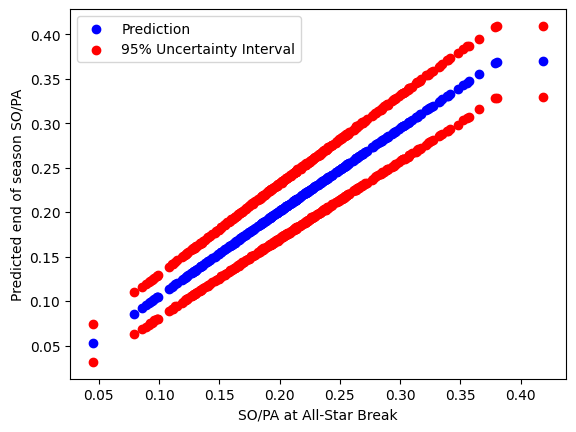

In [ ]:
#Visualize percentile intervals and predictions
plt.scatter(sopaTest, predictions_bnn, label='Prediction', color='blue')
plt.scatter(sopaTest, phigh_bnn, color='red', label='95% Uncertainty Interval')
plt.scatter(sopaTest, plow_bnn, color='red')
plt.legend()
plt.xlabel('SO/PA at All-Star Break')
plt.ylabel('Predicted end of season SO/PA')

In [ ]:
#Calculate widths of percentile intervals
widths_bnn = np.array(phigh_bnn) - np.array(plow_bnn)

Text(0, 0.5, 'Prediction Interval Width')

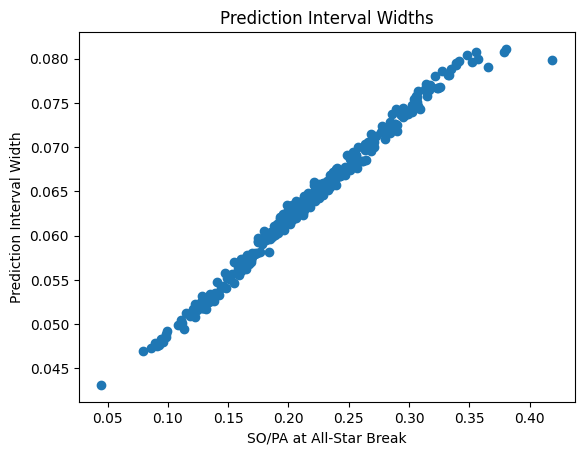

In [ ]:
#Plot percentile interval widths vs actual test values
plt.scatter(sopaTest, widths_bnn)
plt.title('Prediction Interval Widths')
plt.xlabel('SO/PA at All-Star Break')
plt.ylabel('Prediction Interval Width')

#### Let's look at where we went wrong (BNN Percentile Intervals)
---



In [ ]:
#Defining quarters (to be used to analyze both results of BNN and ensemble models)

#Find percentiles (25th, 50th, 75th)
Q1 = np.percentile(sopaTest, 25)
Q2 = np.percentile(sopaTest, 50)
Q3 = np.percentile(sopaTest, 75)

#Check to see which values fall above/below the definined percentiles
ix0 = np.where( (sopaTest >= np.min(sopaTest)) & (sopaTest < Q1) )
ix1 = np.where( (sopaTest >= Q1) & (sopaTest < Q2) )
ix2 = np.where( (sopaTest >= Q2) & (sopaTest < Q3) )
ix3 = np.where( (sopaTest >= Q3) )

In [ ]:
#Checking values by quarters

#Creating empty lists to store widths for each quarter
Q1_per_bnn_widths = []
Q2_per_bnn_widths = []
Q3_per_bnn_widths = []
Q4_per_bnn_widths = []

#For each quarter of data, initialize counter
countQ1_per_bnn = 0

#For each player in the quarter,
for i in ix0[0]:
  #if actual value in the interval, increase counter
  if ( (yTest[i] >= plow_bnn[i]) and (yTest[i] <= phigh_bnn[i]) ): countQ1_per_bnn += 1
  #Find width and add to list
  width = phigh_bnn[i]-plow_bnn[i]
  Q1_per_bnn_widths.append(width)

countQ2_per_bnn = 0
for i in ix1[0]:
  if ( (yTest[i] >= plow_bnn[i]) and (yTest[i] <= phigh_bnn[i]) ): countQ2_per_bnn += 1
  width = phigh_bnn[i]-plow_bnn[i]
  Q2_per_bnn_widths.append(width)

countQ3_per_bnn = 0
for i in ix2[0]:
  if ( (yTest[i] >= plow_bnn[i]) and (yTest[i] <= phigh_bnn[i]) ): countQ3_per_bnn += 1
  width = phigh_bnn[i]-plow_bnn[i]
  Q3_per_bnn_widths.append(width)

countQ4_per_bnn = 0
for i in ix3[0]:
  if ( (yTest[i] >= plow_bnn[i]) and (yTest[i] <= phigh_bnn[i]) ): countQ4_per_bnn += 1
  width = phigh_bnn[i]-plow_bnn[i]
  Q4_per_bnn_widths.append(width)


print(countQ1_per_bnn)
print(countQ2_per_bnn)
print(countQ3_per_bnn)
print(countQ4_per_bnn)

print(len(ix0[0]))
print(len(ix1[0]))
print(len(ix2[0]))
print(len(ix3[0]))

#Find percentage of times actual value falls in interval for each quarter
print("Q1 Percentage:",countQ1_per_bnn/len(ix0[0]))
print("Q2 Percentage:",countQ2_per_bnn/len(ix1[0]))
print("Q3 Percentage:",countQ3_per_bnn/len(ix2[0]))
print("Q4 Percentage:",countQ4_per_bnn/len(ix3[0]))


80
79
79
79
85
83
86
85
Q1 Percentage: 0.9411764705882353
Q2 Percentage: 0.9518072289156626
Q3 Percentage: 0.9186046511627907
Q4 Percentage: 0.9294117647058824


Text(0.5, 1.0, 'Actual values vs our prediction intervals')

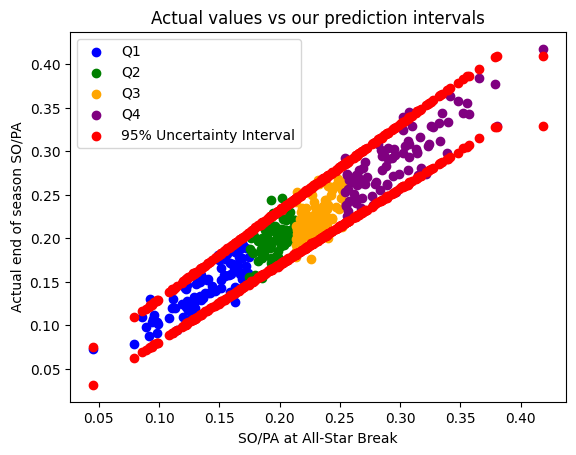

In [ ]:
#Plot actual values with color coding for quarters
plt.scatter(sopaTest[ix0], yTest[ix0], color='blue', label='Q1')
plt.scatter(sopaTest[ix1], yTest[ix1], color='green', label='Q2')
plt.scatter(sopaTest[ix2], yTest[ix2], color='orange', label='Q3')
plt.scatter(sopaTest[ix3], yTest[ix3], color='purple', label='Q4')

#Plot interval bounds
plt.scatter(sopaTest, phigh_bnn, color='red', label='95% Uncertainty Interval')
plt.scatter(sopaTest, plow_bnn, color='red')
plt.legend()
plt.xlabel('SO/PA at All-Star Break')
plt.ylabel('Actual end of season SO/PA')
plt.title('Actual values vs our prediction intervals')

####Normal Prediction Interval Method

In [ ]:
#Calculate total unceratinty
Total_Uncertainty_bnn = aleatoric_bnn + epistemic_bnn
TU_bnn = 1.96*np.sqrt(Total_Uncertainty_bnn) #For 95% interval

In [ ]:
#Calculate standard intervals

#Create empty lists to store upper and lower bounds and interval widths
listWidths_bnn = []
LBs_bnn = []
UBs_bnn=[]

#For each player, add and subtract total unceratinty from final prediction (provides upper and lower bound)
for i in range(339):
  #lower bound
  LB_bnn = predictions_bnn[i] - TU_bnn[i]
  #upper bound
  UB_bnn = predictions_bnn[i] + TU_bnn[i]
  #Calculate width of interval
  width_bnn = UB_bnn-LB_bnn

  #Add values to each list
  listWidths_bnn.append(width_bnn)
  LBs_bnn.append(LB_bnn)
  UBs_bnn.append(UB_bnn)

Text(0.5, 1.0, 'Actual values vs our prediction intervals')

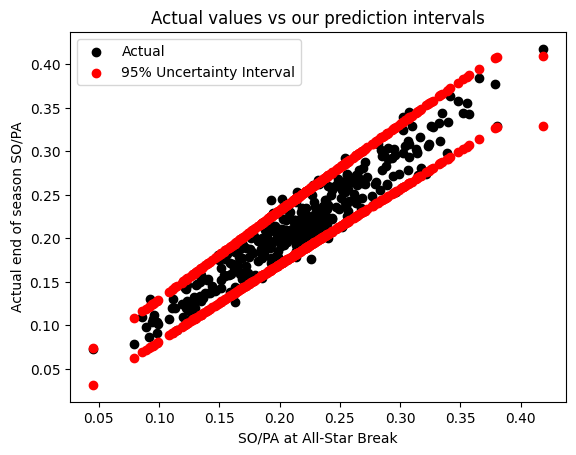

In [ ]:
#Plot Normal Intervals for BNN and actual values
plt.scatter(sopaTest, yTest, label='Actual', color='black')
plt.scatter(sopaTest, UBs_bnn, color='red', label='95% Uncertainty Interval')
plt.scatter(sopaTest, LBs_bnn, color='red')
plt.legend()
plt.xlabel('SO/PA at All-Star Break')
plt.ylabel('Actual end of season SO/PA')
plt.title('Actual values vs our prediction intervals')

Text(0, 0.5, 'Prediction Interval Width')

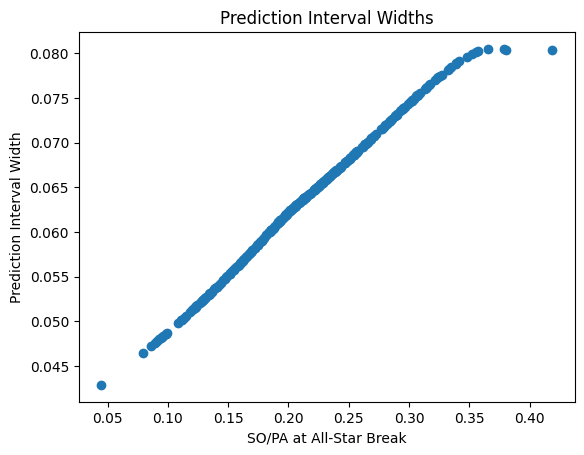

In [ ]:
#Plot widths of intervals vs actual values
plt.scatter(sopaTest, listWidths_bnn)
plt.title('Prediction Interval Widths')
plt.xlabel('SO/PA at All-Star Break')
plt.ylabel('Prediction Interval Width')

In [ ]:
#Checking quarters

#Create empty lists for each quarter
Q1_st_bnn_widths = []
Q2_st_bnn_widths = []
Q3_st_bnn_widths = []
Q4_st_bnn_widths = []

#For each quarter, initialize counter
countQ1_st_bnn = 0
#For each value in the quarter, test to see if the interval contains the acutal value, increment counter accordingly
for i in ix0[0]:
  if ( (yTest[i] >= LBs_bnn[i]) and (yTest[i] <= UBs_bnn[i]) ): countQ1_st_bnn += 1
  #Find width and add to appropriate list
  width = UBs_bnn[i] - LBs_bnn[i]
  Q1_st_bnn_widths.append(width)

countQ2_st_bnn = 0
for i in ix1[0]:
  if ( (yTest[i] >= LBs_bnn[i]) and (yTest[i] <= UBs_bnn[i]) ): countQ2_st_bnn += 1
  width = UBs_bnn[i] - LBs_bnn[i]
  Q2_st_bnn_widths.append(width)

countQ3_st_bnn = 0
for i in ix2[0]:
  if ( (yTest[i] >= LBs_bnn[i]) and (yTest[i] <= UBs_bnn[i]) ): countQ3_st_bnn += 1
  width = UBs_bnn[i] - LBs_bnn[i]
  Q3_st_bnn_widths.append(width)

countQ4_st_bnn = 0
for i in ix3[0]:
  if ( (yTest[i] >= LBs_bnn[i]) and (yTest[i] <= UBs_bnn[i]) ): countQ4_st_bnn += 1
  width = UBs_bnn[i] - LBs_bnn[i]
  Q4_st_bnn_widths.append(width)

#Find percentage of times interval contains actual value for each quarter
print("Q1 Percentage:",countQ1_st_bnn/len(ix0[0]))
print("Q2 Percentage:",countQ2_st_bnn/len(ix1[0]))
print("Q3 Percentage:",countQ3_st_bnn/len(ix2[0]))
print("Q4 Percentage:",countQ4_st_bnn/len(ix3[0]))

Q1 Percentage: 0.9411764705882353
Q2 Percentage: 0.9518072289156626
Q3 Percentage: 0.9186046511627907
Q4 Percentage: 0.9294117647058824


(0.0, 0.45)

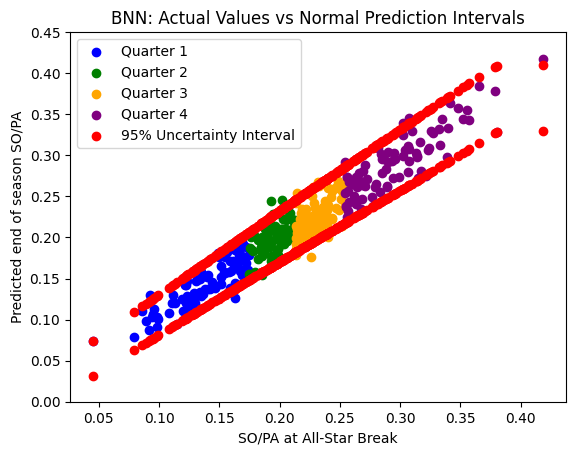

In [ ]:
#Plot actual values color coded by quarter
plt.scatter(sopaTest[ix0], yTest[ix0], color='blue', label='Quarter 1')
plt.scatter(sopaTest[ix1], yTest[ix1], color='green', label='Quarter 2')
plt.scatter(sopaTest[ix2], yTest[ix2], color='orange', label='Quarter 3')
plt.scatter(sopaTest[ix3], yTest[ix3], color='purple', label='Quarter 4')

#Plot intervals
plt.scatter(sopaTest, LBs_bnn, color='red', label='95% Uncertainty Interval')
plt.scatter(sopaTest, UBs_bnn, color='red')
plt.legend()
plt.xlabel('SO/PA at All-Star Break')
plt.ylabel('Predicted end of season SO/PA')
plt.title('BNN: Actual Values vs Normal Prediction Intervals')
plt.ylim(0.00, 0.45)

###Develop Methods to Construct and Evaluate Ensemble Approach

In [ ]:
#Define Loss function (negative log-likelihood)
def nll_loss(y_true, y_pred):
    mean = y_pred[:, 0:1] #extract mean branch
    var  = y_pred[:, 1:2] #extract variance branch

    var = var + 1e-6 # numerical stability
    return 0.5 * (
        tf.math.log(var) + tf.square(y_true - mean) / var
    )

In [ ]:
#Define MAE function to specifically calculate MAE for the mean branch only
def mean_mae(y_true, y_pred):
    mean = y_pred[:, 0:1] #extract mean branch
    return tf.reduce_mean(tf.abs(y_true - mean)) #Absolute value of true value - prediction

In [ ]:
#Function to build ensemble model
def generateAndTrainModel(name):
    print("Training:", name)

    #Start timer
    start = time.time()

    #SO/PA at ASG
    inputs = tf_keras.layers.Input(shape=(1,))

    #Shared trunk
    #Hidden layer 1
    x = tf_keras.layers.Dense(6, activation='relu')(inputs)
    #Hidden layer 2
    x = tf_keras.layers.Dense(3, activation='relu')(x)

    #Mean output
    mean = tf_keras.layers.Dense(1, activation='linear')(x)

    #Variance output
    var = tf_keras.layers.Dense(1, activation='softplus')(x)

    #Concatenate mean + var into a single tensor
    outputs = tf_keras.layers.Concatenate(name="mean_var_output")([mean, var])

    model = tf_keras.models.Model(inputs=inputs, outputs=outputs)

    optimizer = tf_keras.optimizers.Adam(
      learning_rate=0.001,
      beta_1=0.9,
      beta_2=0.999,
      epsilon=1e-8,   # IMPORTANT: Keras 2 default was 1e-7
      amsgrad=False
    )

    #Compile model with nll loss and MAE metric to monitor during training
    model.compile(optimizer=optimizer, loss=nll_loss,metrics=[mean_mae])

    #Fit model, validation split of 10%
    h=model.fit(sopaTrain,yTrain,epochs=500,batch_size=64,verbose=1, validation_split=0.1)

    #Define 2 histories - loss and MAE
    history1 = h.history['loss']
    history2 = h.history['val_mean_mae']

    #End timer
    end = time.time()

    #How long did it take to train?
    duration = end - start
    print("   Training time (minutes)", np.round(duration/60., 2))

    return model, history1, history2

#Define function to get predictions from trained model
def getModelPrediction(model, val):
    y_pred = model.predict(val)
    return y_pred

In [ ]:
#5 different networks as part of the ensemble

#Empty lists to store predictions
means_ens = []
variances_ens = []
means_ens_Train = []

#Start timer
s = time.time()

# model 1
#Each model has a different random seed to introduce variability
random.seed(42)
#Train model
model1 = generateAndTrainModel('model_1')
#Results with test data
result = getModelPrediction(model1[0],sopaTest)
#Add results to lists
means_ens.append(result[:,0])
variances_ens.append(result[:,1])
#Results with training data
result2 = getModelPrediction(model1[0],sopaTrain)
#Add results to list
means_ens_Train.append(result2[:,0])

# model 2
random.seed(43)
model2 = generateAndTrainModel('model_2')
result = getModelPrediction(model2[0],sopaTest)
means_ens.append(result[:,0])
variances_ens.append(result[:,1])
result2 = getModelPrediction(model2[0],sopaTrain)
means_ens_Train.append(result2[:,0])

# model 3
random.seed(44)
model3 = generateAndTrainModel('model_3')
result = getModelPrediction(model3[0],sopaTest)
means_ens.append(result[:,0])
variances_ens.append(result[:,1])
result2 = getModelPrediction(model3[0],sopaTrain)
means_ens_Train.append(result2[:,0])

# model 4
random.seed(45)
model4 = generateAndTrainModel('model_4')
result = getModelPrediction(model4[0],sopaTest)
means_ens.append(result[:,0])
variances_ens.append(result[:,1])
result2 = getModelPrediction(model4[0],sopaTrain)
means_ens_Train.append(result2[:,0])

# model 5
random.seed(46)
model5 = generateAndTrainModel('model_5')
result = getModelPrediction(model5[0],sopaTest)
means_ens.append(result[:,0])
variances_ens.append(result[:,1])
result2 = getModelPrediction(model5[0],sopaTrain)
means_ens_Train.append(result2[:,0])

#Stop timer
e = time.time()

#How long did it take to train all models?
duration = e - s
print("Total training time (minutes)", np.round(duration/60.,2))



Streaming output truncated to the last 5000 lines.
Epoch 11/500
15/15 [==============================] - 0s 4ms/step - loss: -0.2339 - mean_mae: 0.0819 - val_loss: -0.2374 - val_mean_mae: 0.0829
Epoch 12/500
15/15 [==============================] - 0s 4ms/step - loss: -0.2407 - mean_mae: 0.0742 - val_loss: -0.2442 - val_mean_mae: 0.0760
Epoch 13/500
15/15 [==============================] - 0s 4ms/step - loss: -0.2474 - mean_mae: 0.0680 - val_loss: -0.2508 - val_mean_mae: 0.0702
Epoch 14/500
15/15 [==============================] - 0s 4ms/step - loss: -0.2539 - mean_mae: 0.0624 - val_loss: -0.2573 - val_mean_mae: 0.0652
Epoch 15/500
15/15 [==============================] - 0s 4ms/step - loss: -0.2604 - mean_mae: 0.0592 - val_loss: -0.2637 - val_mean_mae: 0.0615
Epoch 16/500
15/15 [==============================] - 0s 4ms/step - loss: -0.2667 - mean_mae: 0.0561 - val_loss: -0.2700 - val_mean_mae: 0.0582
Epoch 17/500
15/15 [==============================] - 0s 4ms/step - loss: -0.2729 - m

In [ ]:
# save model weights, serialize weights to HDF5
model1[0].save_weights(dir+"ensemble_1SO.weights.h5")
model2[0].save_weights(dir+"ensemble_2SO.weights.h5")
model3[0].save_weights(dir+"ensemble_3SO.weights.h5")
model4[0].save_weights(dir+"ensemble_4SO.weights.h5")
model5[0].save_weights(dir+"ensemble_5SO.weights.h5")

In [ ]:
#Model architecture
model1[0].summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_6 (InputLayer)        [(None, 1)]                  0         []                            
                                                                                                  
 dense_5 (Dense)             (None, 6)                    12        ['input_6[0][0]']             
                                                                                                  
 dense_6 (Dense)             (None, 3)                    21        ['dense_5[0][0]']             
                                                                                                  
 dense_7 (Dense)             (None, 1)                    4         ['dense_6[0][0]']             
                                                                                              

In [ ]:
#Ratio of parameters in model to training size
#Total parameters (model 1) - 41
#Validation -> 0.1 * 1016 = 101.6 (101)
#Training set size -> 1016 - 101 = 915
#Validation
ens_ratio = 41/915
print(f"Ensemble ratio: {ens_ratio:.6f}")

Ensemble ratio: 0.044809


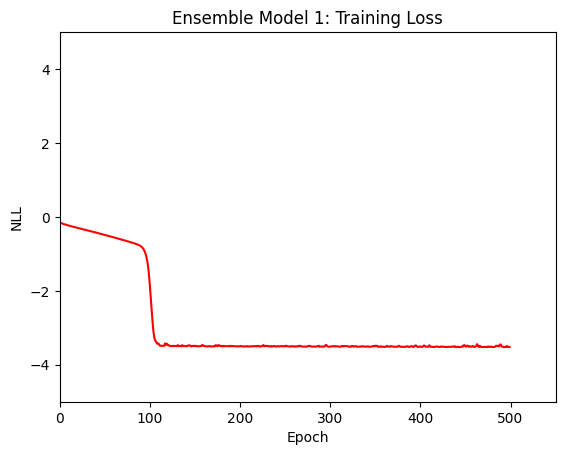

In [ ]:
#Visualize training loss of the first model
train_loss = model1[1]  # Training loss per epoch
plt.plot(train_loss, color = 'red')
plt.title('Ensemble Model 1: Training Loss')
plt.ylabel('NLL')
plt.xlabel('Epoch')
plt.ylim(-5,5)

#save image

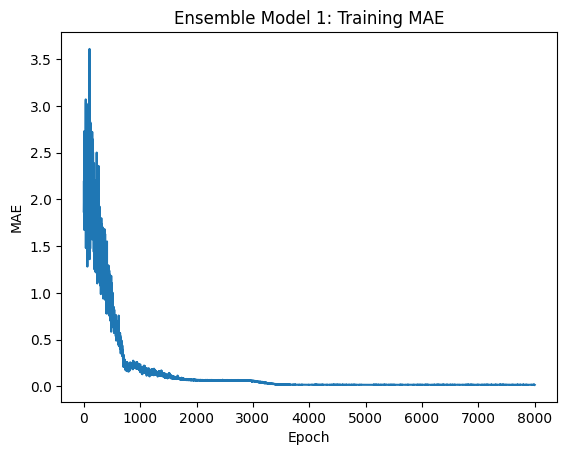

In [ ]:
#Visualize MAE
train_mae = model1[2]  # Training accuracy per epoch, 2nd index returns history2 (MAE)
plt.plot(train_accuracy)
plt.title('Ensemble Model 1: Training MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')

#save image

#### *Only run if re-loading weights from previously trained model*

In [ ]:
#IF reloading weights (not training model), this method will setup model architecture
def setupModel():

    #SO/PA at ASG
    inputs = tf_keras.layers.Input(shape=(1,))

    #Shared trunk
    #Hidden layer 1
    x = tf_keras.layers.Dense(6, activation='relu')(inputs)
    #Hidden layer 2
    x = tf_keras.layers.Dense(3, activation='relu')(x)

    #Mean output
    mean = tf_keras.layers.Dense(1, activation='linear')(x)

    #Variance output
    var = tf_keras.layers.Dense(1, activation='softplus')(x)

    #Concatenate mean + var into a single tensor [batch, 2]
    outputs = tf_keras.layers.Concatenate(name="mean_var_output")([mean, var])

    model = tf_keras.models.Model(inputs=inputs, outputs=outputs)

    #optimizer = tf_keras.optimizers.Adam()
    optimizer = tf_keras.optimizers.Adam(
      learning_rate=0.001,
      beta_1=0.9,
      beta_2=0.999,
      epsilon=1e-8,   # IMPORTANT: Keras 2 default was 1e-7
      amsgrad=False
    )
    #Compile model with nll loss
    model.compile(optimizer=optimizer, loss=nll_loss)
    return model

In [ ]:
#Load weights from previously trained model
model1= setupModel()
model1.load_weights(dir+"ensemble_1SO.weights.h5")
model2= setupModel()
model2.load_weights(dir+"ensemble_2SO.weights.h5")
model3= setupModel()
model3.load_weights(dir+"ensemble_3SO.weights.h5")
model4= setupModel()
model4.load_weights(dir+"ensemble_4SO.weights.h5")
model5= setupModel()
model5.load_weights(dir+"ensemble_5SO.weights.h5")

In [ ]:
#Recalculate predictions with previously trained model

#Empty lists to store info
means_ens = []
variances_ens = []
means_ens_Train = []

#Model 1
#Results with test data
result = getModelPrediction(model1,sopaTest)
#Add to lists
means_ens.append(result[:,0])
variances_ens.append(result[:,1])
#Results with training data
result2 = getModelPrediction(model1,sopaTrain)
#Add to list
means_ens_Train.append(result2[:,0])

#Model 2
result = getModelPrediction(model2,sopaTest)
means_ens.append(result[:,0])
variances_ens.append(result[:,1])
result2 = getModelPrediction(model2,sopaTrain)
means_ens_Train.append(result2[:,0])

#Model 3
result = getModelPrediction(model3,sopaTest)
means_ens.append(result[:,0])
variances_ens.append(result[:,1])
result2 = getModelPrediction(model3,sopaTrain)
means_ens_Train.append(result2[:,0])

#Model 4
result = getModelPrediction(model4,sopaTest)
means_ens.append(result[:,0])
variances_ens.append(result[:,1])
result2 = getModelPrediction(model4,sopaTrain)
means_ens_Train.append(result2[:,0])

#Model 5
result = getModelPrediction(model4,sopaTest)
means_ens.append(result[:,0])
variances_ens.append(result[:,1])
result2 = getModelPrediction(model4,sopaTrain)
means_ens_Train.append(result2[:,0])

32/32 [==============================] - 0s 1ms/step


###Evaluate Ensemble Approach

Aleatoric and Epistemic Uncertainty

We already have 5 distributions (mean and variance) for each player from the ensemble model's output.

In [ ]:
#Convert means to numpy array
means_ens = np.array(means_ens)

In [ ]:
#Convert variances to numpy array
variances_ens = np.array(variances_ens)

In [ ]:
#Aleatoric Uncertainty
aleatoric_ens=getAleatoric(variances_ens)

In [ ]:
#Epsitemic Uncertainty
epistemic_ens = getEpistemic(means_ens)

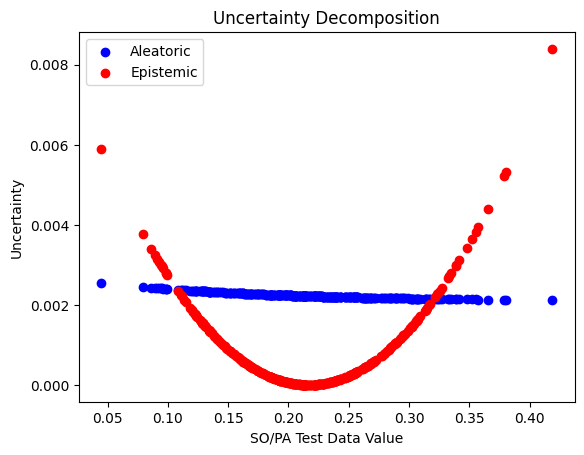

In [ ]:
#Plot aleatoric and epistemic uncertainty, scatterplot
plt.scatter(sopaTest, aleatoric_ens, label='Aleatoric', color='blue')
plt.scatter(sopaTest, epistemic_ens, label='Epistemic', color='red')
plt.title('Uncertainty Decomposition')
plt.xlabel('SO/PA Test Data Value')
plt.ylabel('Uncertainty')
plt.legend()

MAE of Testing and Training Data

In [ ]:
#Final prediction for each player is mean of 5 ensemble "means"
meanof5List_ens= np.mean(means_ens,axis=0)

In [ ]:
#Calculate MAE between final prediction and actual value (test data)
mean_absolute_error(meanof5List_ens, yTest)

0.03062301911804922

In [ ]:
#Convert training data to numpy array
meansNP_ens_Train = np.array(means_ens_Train)
#Take average of 5 ensemble predictions for training data
meanof5List_ens_Train= np.mean(meansNP_ens_Train,axis=0)

In [ ]:
#Calculate MAE of training data (to assess overfitting, underfitting)
mean_absolute_error(meanof5List_ens_Train, yTrain )

0.03089975360569157

##### How do Ensemble predictions compare to actual SO/PA?

Text(0, 0.5, 'Number of Occurences')

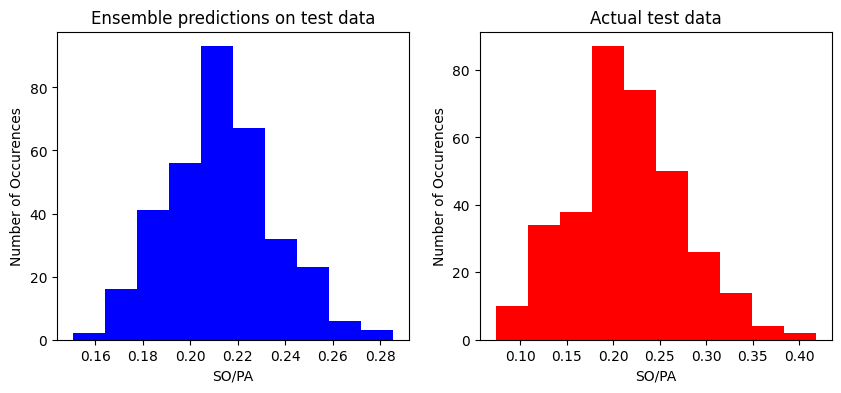

In [ ]:
#Histograms of predicted EOS SO/PA values and actual EOS SO/PA values to compare distributions
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# First subplot (left)
axs[0].hist(meanof5List_ens, color='blue')
axs[0].set_title('Ensemble predictions on test data')
axs[0].set_xlabel('SO/PA')
axs[0].set_ylabel('Number of Occurences')

# Second subplot (right)
axs[1].hist(yTest, color='red')
axs[1].set_title('Actual test data')
axs[1].set_xlabel('SO/PA')
axs[1].set_ylabel('Number of Occurences')

(0.0, 0.45)

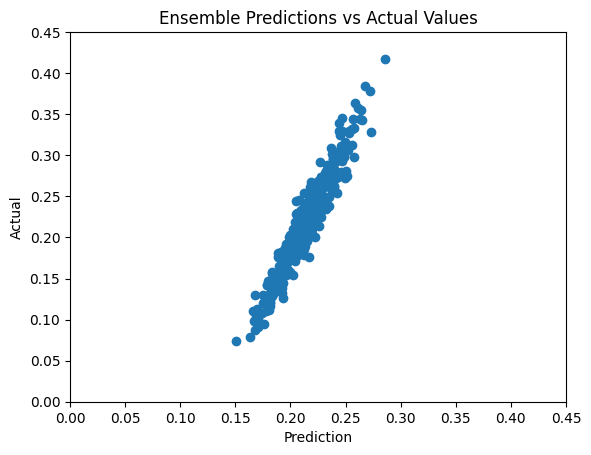

In [ ]:
#Scatterplot of actual values vs predictions (should be roughly linear)
plt.scatter(meanof5List_ens, yTest)
plt.title('Ensemble Predictions vs Actual Values')
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.xlim(0,.45)
plt.ylim(0,.45)

#####Percentile Based Prediction Interval

In [ ]:
#Get 1000 samples from each of the 5 distributions for each player
# number of players in our test data
n = 339
#shape->(5,339)

#array to hold our results
samples_ens = np.zeros( shape=(5000,n) )

#loop over every player in the test data
for i in range(n):

  #empty list to store samples
  s = []

  # status update
  if ( i == 100 ): print("Working on player 100 of", n)
  if ( i == 200 ): print("Working on player 200 of", n)
  if ( i == 300 ): print("Working on player 300 of", n)

  # we created 5 predictions (mean/variance) for each player so we loop 5 times
  for j in range(5):

    # what is the jth prediction for this player?
    mean_ens = means_ens[j,i]
    variance_ens = variances_ens[j,i]

    # we have variance, but need standard deviation (take square root)
    sd_ens = np.sqrt(variance_ens)

    # take samples from this predicted normal distribution
    # we'll use 1000 - the more you take the better the estimate, but the slower the loop
    sample_ens = np.random.normal(loc=mean_ens, scale=sd_ens, size=1000)
    s.extend(sample_ens)

  # before moving on to the next player, add the samples to our array
  samples_ens[:,i] = s

Working on player 100 of 339
Working on player 200 of 339
Working on player 300 of 339


In [ ]:
#Calculating 95th percentile intervals for each player
#Empty lists to store upper and lower bounds
plow_ens = []
phigh_ens = []

#initialize count to track number of times interval contains actual value
count = 0

for i in range(339): #for all players
  #Calculate percentiles at 2.5% and 97.5% (middle 95% of data) and store in lists
  plow_ens.append( np.percentile(samples_ens[:,i], 2.5) )
  phigh_ens.append( np.percentile(samples_ens[:,i], 97.5) )

  #If actual value in the interval, increase counter
  if ( (yTest[i] >= plow_ens[i]) and (yTest[i] <= phigh_ens[i]) ): count += 1

#Calculate percentage of times interval contains actual value
print("We expect 95% of the actual values to be within 95% intervals")
print("We get", np.round(count/339,4)*100, "%")

We expect 95% of the actual values to be within 95% intervals
We get 96.76 %


Text(0.5, 1.0, 'Actual values vs our prediction intervals')

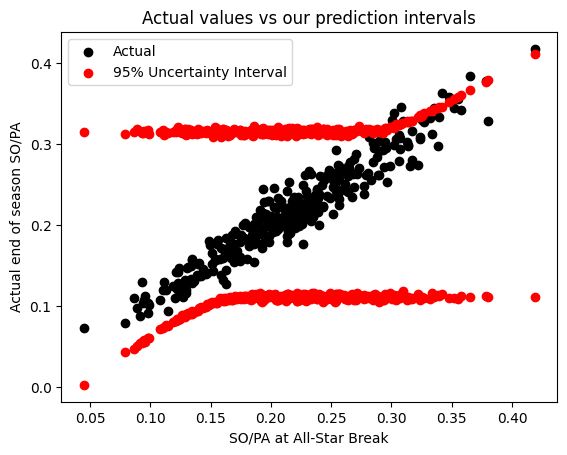

In [ ]:
#Plot intervals and actual values in scatterplot
plt.scatter(sopaTest, yTest, label='Actual', color='black')
plt.scatter(sopaTest, phigh_ens, color='red', label='95% Uncertainty Interval')
plt.scatter(sopaTest, plow_ens, color='red')
plt.legend()
plt.xlabel('SO/PA at All-Star Break')
plt.ylabel('Actual end of season SO/PA')
plt.title('Actual values vs our prediction intervals')

In [ ]:
#Calculate widths of percentile intervals
widths_ens = np.array(phigh_ens) - np.array(plow_ens)


Text(0, 0.5, 'Prediction Interval Width')

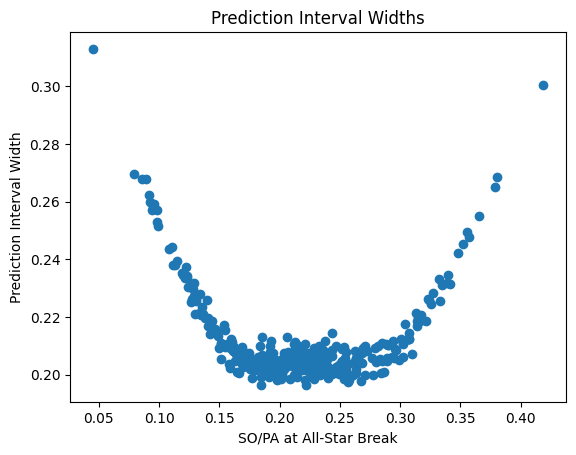

In [ ]:
#Visualize widths of intervals (scatterplot)
plt.scatter(sopaTest, widths_ens)
plt.title('Prediction Interval Widths')
plt.xlabel('SO/PA at All-Star Break')
plt.ylabel('Prediction Interval Width')

###### Let's look at where we went wrong

In [ ]:
#Checking values by quarter

#Define empty lists to store values
Q1_per_ens_widths = []
Q2_per_ens_widths = []
Q3_per_ens_widths = []
Q4_per_ens_widths = []

#Initialize counter
countQ1_per_ens = 0
#For values in quarter 1, check to see if the interval contained the actual value
for i in ix0[0]:
  #If yes, counter increases
  if ( (yTest[i] >= plow_ens[i]) and (yTest[i] <= phigh_ens[i]) ): countQ1_per_ens += 1
  #Add width to list for that quarter
  width = phigh_ens[i]-plow_ens[i]
  Q1_per_ens_widths.append(width)

countQ2_per_ens = 0
for i in ix1[0]:
  if ( (yTest[i] >= plow_ens[i]) and (yTest[i] <= phigh_ens[i]) ): countQ2_per_ens += 1
  width = phigh_ens[i]-plow_ens[i]
  Q2_per_ens_widths.append(width)

countQ3_per_ens = 0
for i in ix2[0]:
  if ( (yTest[i] >= plow_ens[i]) and (yTest[i] <= phigh_ens[i]) ): countQ3_per_ens += 1
  width = phigh_ens[i]-plow_ens[i]
  Q3_per_ens_widths.append(width)

countQ4_per_ens = 0
for i in ix3[0]:
  if ( (yTest[i] >= plow_ens[i]) and (yTest[i] <= phigh_ens[i]) ): countQ4_per_ens += 1
  width = phigh_ens[i]-plow_ens[i]
  Q4_per_ens_widths.append(width)

#Calculate percentage of times interval contains actual value for each quarter
print("Q1 Percentage:",countQ1_per_ens/len(ix0[0]))
print("Q2 Percentage:",countQ2_per_ens/len(ix1[0]))
print("Q3 Percentage:",countQ3_per_ens/len(ix2[0]))
print("Q4 Percentage:",countQ4_per_ens/len(ix3[0]))

Q1 Percentage: 1.0
Q2 Percentage: 1.0
Q3 Percentage: 1.0
Q4 Percentage: 0.8705882352941177


Text(0, 0.5, 'Predicted end of season SO/PA')

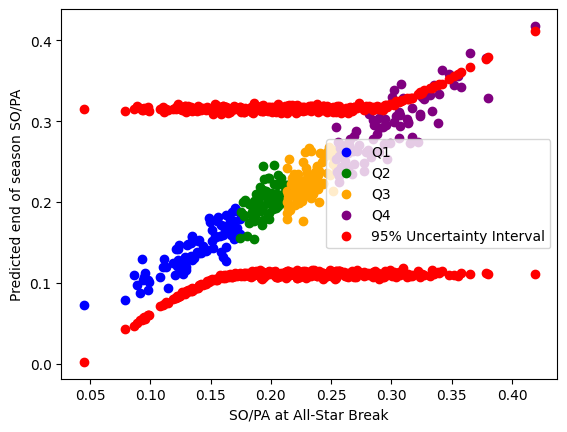

In [ ]:
#Plot color-coded quarters (actual values)
plt.scatter(sopaTest[ix0], yTest[ix0], color='blue', label='Q1')
plt.scatter(sopaTest[ix1], yTest[ix1], color='green', label='Q2')
plt.scatter(sopaTest[ix2], yTest[ix2], color='orange', label='Q3')
plt.scatter(sopaTest[ix3], yTest[ix3], color='purple', label='Q4')

#Plot intervals
plt.scatter(sopaTest, phigh_ens, color='red', label='95% Uncertainty Interval')
plt.scatter(sopaTest, plow_ens, color='red')
plt.legend()
plt.xlabel('SO/PA at All-Star Break')
plt.ylabel('Predicted end of season SO/PA')

#####Normal Prediction Intervals

In [ ]:
#Calculate total unceratinty
Total_Uncertainty_ens = aleatoric_ens + epistemic_ens
MOE_ens = 1.96*np.sqrt(Total_Uncertainty_ens) #95% interval

In [ ]:
#Initalize empty lists to store upper and lower bounds for standard intervals
listWidths_ens = []
LBs_ens = []
UBs_ens=[]
#For each player, calculate upper and lower bound (add and subtract total uncertainty from prediction)
for i in range(339):
  LB_ens = meanof5List_ens[i] - MOE_ens[i]
  UB_ens = meanof5List_ens[i] + MOE_ens[i]
  #Calculate width (difference between upper and lower bound)
  width_ens = UB_ens-LB_ens
  #Add to appropriate lists
  listWidths_ens.append(width_ens)
  LBs_ens.append(LB_ens)
  UBs_ens.append(UB_ens)

Text(0.5, 1.0, 'Actual values vs our prediction intervals')

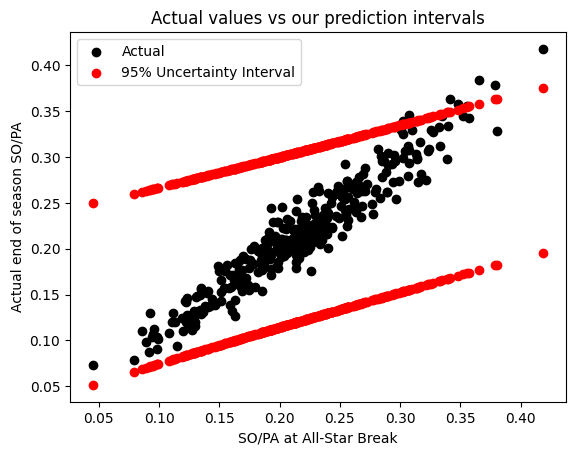

In [ ]:
#Scatterplot of normal intervals and actual values
plt.scatter(sopaTest, yTest, label='Actual', color='black')
plt.scatter(sopaTest, UBs_ens, color='red', label='95% Uncertainty Interval')
plt.scatter(sopaTest, LBs_ens, color='red')
plt.legend()
plt.xlabel('SO/PA at All-Star Break')
plt.ylabel('Actual end of season SO/PA')
plt.title('Actual values vs our prediction intervals')

Text(0, 0.5, 'Prediction Interval Width')

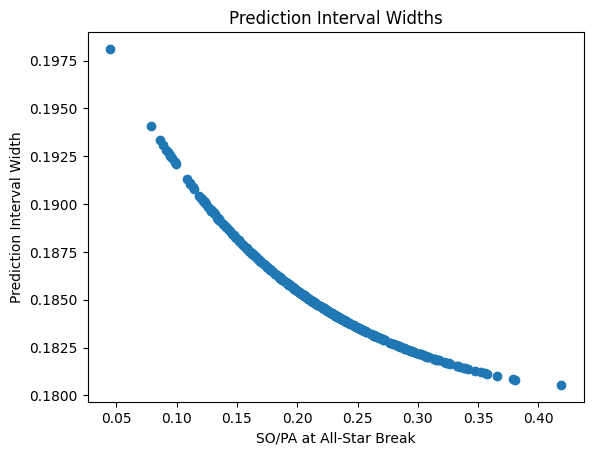

In [ ]:
#Scatterplot of normal intervals widths vs actual values
plt.scatter(sopaTest, listWidths_ens)
plt.title('Prediction Interval Widths')
plt.xlabel('SO/PA at All-Star Break')
plt.ylabel('Prediction Interval Width')

In [ ]:
#Checking values by quarter

#Empty lists to store widths for each quarter
Q1_st_ens_widths = []
Q2_st_ens_widths = []
Q3_st_ens_widths = []
Q4_st_ens_widths = []

#For each quarter, initialize counter
countQ1_st_ens = 0
#For each value in the quarter, check if the interval contains the actual value, increase counter accordingly
for i in ix0[0]:
  if ( (yTest[i] >= LBs_ens[i]) and (yTest[i] <= UBs_ens[i]) ): countQ1_st_ens += 1
  #Add width to list
  width = UBs_ens[i]-LBs_ens[i]
  Q1_st_ens_widths.append(width)

countQ2_st_ens = 0
for i in ix1[0]:
  if ( (yTest[i] >= LBs_ens[i]) and (yTest[i] <= UBs_ens[i]) ): countQ2_st_ens += 1
  width = UBs_ens[i]-LBs_ens[i]
  Q2_st_ens_widths.append(width)

countQ3_st_ens = 0
for i in ix2[0]:
  if ( (yTest[i] >= LBs_ens[i]) and (yTest[i] <= UBs_ens[i]) ): countQ3_st_ens += 1
  width = UBs_ens[i]-LBs_ens[i]
  Q3_st_ens_widths.append(width)

countQ4_st_ens = 0
for i in ix3[0]:
  if ( (yTest[i] >= LBs_ens[i]) and (yTest[i] <= UBs_ens[i]) ): countQ4_st_ens += 1
  width = UBs_ens[i]-LBs_ens[i]
  Q4_st_ens_widths.append(width)

#Calculate percentage of times interval contained actual value for each quarter
print("Q1 Percentage:",countQ1_st_ens/len(ix0[0]))
print("Q2 Percentage:",countQ2_st_ens/len(ix1[0]))
print("Q3 Percentage:",countQ3_st_ens/len(ix2[0]))
print("Q4 Percentage:",countQ4_st_ens/len(ix3[0]))

Q1 Percentage: 1.0
Q2 Percentage: 1.0
Q3 Percentage: 1.0
Q4 Percentage: 0.9058823529411765


#Side by Side Plots


###Plots formatted for ease of comparing both models. Some plots are repeated from above.

In [ ]:
#set default font size to 10
plt.rcParams.update({
    "font.size": 10
})

In [ ]:
#Letters to define subplots
letters = string.ascii_uppercase

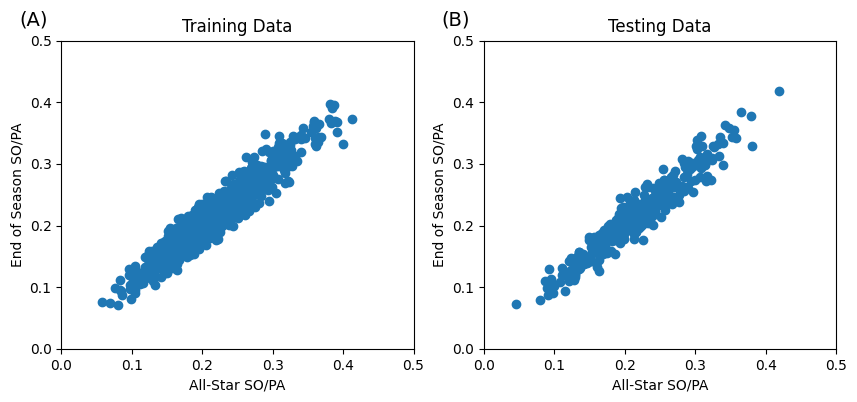

In [ ]:
#1 row with 2 figures
fig, axs = plt.subplots(1,2,figsize = (10,4))

#Plot EOS SO/PA vs ASG SO/PA for training data
axs[0].scatter(sopaTrain, yTrain)
axs[0].set_title('Training Data')
axs[0].set_xlabel('All-Star SO/PA')
axs[0].set_ylabel('End of Season SO/PA')
axs[0].set_xlim(0,.5)
axs[0].set_ylim(0,.5)

#Plot EOS SO/PA vs ASG SO/PA for testing data
axs[1].scatter(sopaTest, yTest)
axs[1].set_title('Testing Data')
axs[1].set_xlabel('All-Star SO/PA')
axs[1].set_ylabel('End of Season SO/PA')
axs[1].set_xlim(0,.5)
axs[1].set_ylim(0,.5)

#For each sub-plot, add a letter in top left corner
for i, ax in enumerate(axs):
    ax.text(
        -0.12, 1.1,
        f'({letters[i]})',
        transform=ax.transAxes,
        fontsize=14,
        va='top'
    )

#Export image

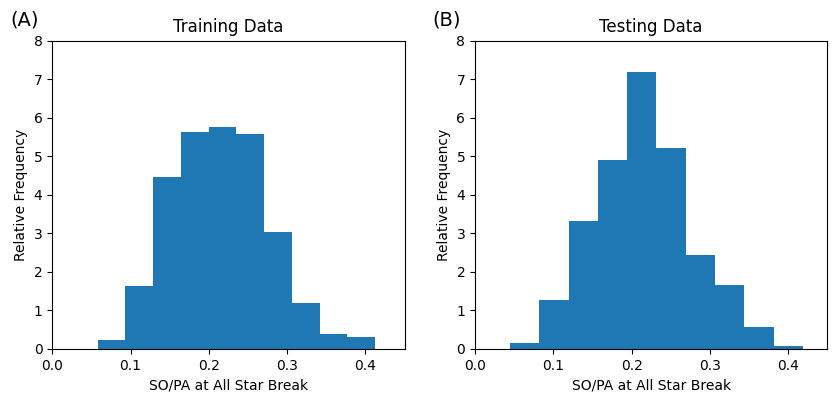

In [ ]:
#1 row, 2 plots
#Histograms - training and testing inputs
fig, axs = plt.subplots(1,2,figsize = (10,4))

#Histogram of training data ASG SO/PA
axs[0].hist(sopaTrain, density = True)
axs[0].set_title('Training Data')
axs[0].set_xlabel('SO/PA at All Star Break')
axs[0].set_ylabel('Relative Frequency')
axs[0].xaxis.set_major_locator(ticker.MultipleLocator(0.1))
axs[0].set_xlim(0,0.45)
axs[0].set_ylim(0,8)

#Histogram of testing data ASG SO/PA
axs[1].hist(sopaTest, density = True)
axs[1].set_title('Testing Data')
axs[1].set_xlabel('SO/PA at All Star Break')
axs[1].set_ylabel('Relative Frequency')
axs[1].xaxis.set_major_locator(ticker.MultipleLocator(0.1))
axs[1].set_xlim(0,0.45)
axs[1].set_ylim(0,8)

#For each sub-plot, add a letter in top left corner
for i, ax in enumerate(axs):
    # your plotting command here
    # ax.hist(data[i])

    ax.text(
        -0.12, 1.1,
        f'({letters[i]})',
        transform=ax.transAxes,
        fontsize=14,
        va='top'
    )

#Export image

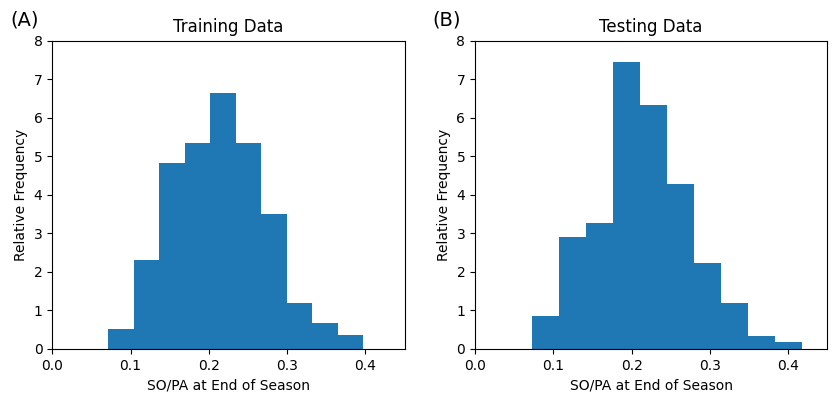

In [ ]:
#1 row, 2 plots
#Histograms - training and testing outputs
fig, axs = plt.subplots(1,2,figsize = (10,4))

#Histogram of training data EOS SO/PA
axs[0].hist(yTrain, density = True)
axs[0].set_title('Training Data')
axs[0].set_xlabel('SO/PA at End of Season')
axs[0].set_ylabel('Relative Frequency')
axs[0].xaxis.set_major_locator(ticker.MultipleLocator(0.1))
axs[0].set_xlim(0,0.45)
axs[0].set_ylim(0,8)

#Histogram of testing data EOS SO/PA
axs[1].hist(yTest, density = True)
axs[1].set_title('Testing Data')
axs[1].set_xlabel('SO/PA at End of Season')
axs[1].set_ylabel('Relative Frequency')
axs[1].xaxis.set_major_locator(ticker.MultipleLocator(0.1))
axs[1].set_xlim(0,0.45)
axs[1].set_ylim(0,8)

#For each sub-plot, add a letter in top left corner
for i, ax in enumerate(axs):
    # your plotting command here
    # ax.hist(data[i])

    ax.text(
        -0.12, 1.1,
        f'({letters[i]})',
        transform=ax.transAxes,
        fontsize=14,
        va='top'
    )
#Export image

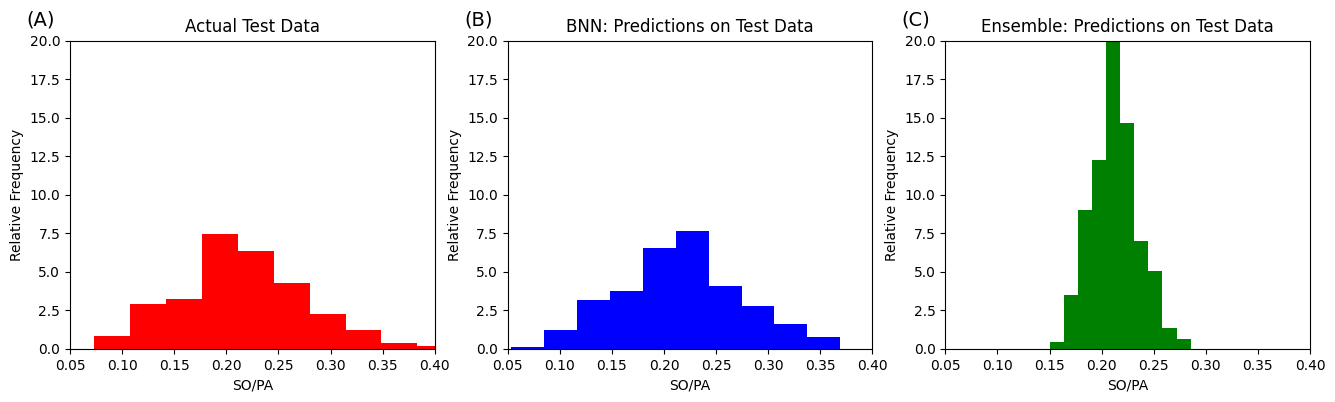

In [ ]:
#1 row, 3 plots
fig, axs = plt.subplots(1, 3, figsize=(16, 4))

#Histogram of actual test data (left)
axs[0].hist(yTest, color='red', density = True)
axs[0].set_title('Actual Test Data')
axs[0].set_xlabel('SO/PA')
axs[0].set_ylabel('Relative Frequency')
axs[0].set_xlim(0.05, 0.40)
axs[0].set_ylim(0, 20)

#Histogram of BNN predictions (middle)
axs[1].hist(predictions_bnn, color='blue', density = True)
axs[1].set_title('BNN: Predictions on Test Data')
axs[1].set_xlabel('SO/PA')
axs[1].set_ylabel('Relative Frequency')
axs[1].set_xlim(0.05, 0.40)
axs[1].set_ylim(0, 20)

#Histogram of ensemble predictions (right)
axs[2].hist(meanof5List_ens, color='green', density = True)
axs[2].set_title('Ensemble: Predictions on Test Data')
axs[2].set_xlabel('SO/PA')
axs[2].set_ylabel('Relative Frequency')
axs[2].set_xlim(0.05, 0.40)
axs[2].set_ylim(0, 20)

#For each sub-plot, add a letter in top left corner
for i, ax in enumerate(axs):
    # your plotting command here
    # ax.hist(data[i])

    ax.text(
        -0.12, 1.1,
        f'({letters[i]})',
        transform=ax.transAxes,
        fontsize=14,
        va='top'
    )

#Export image

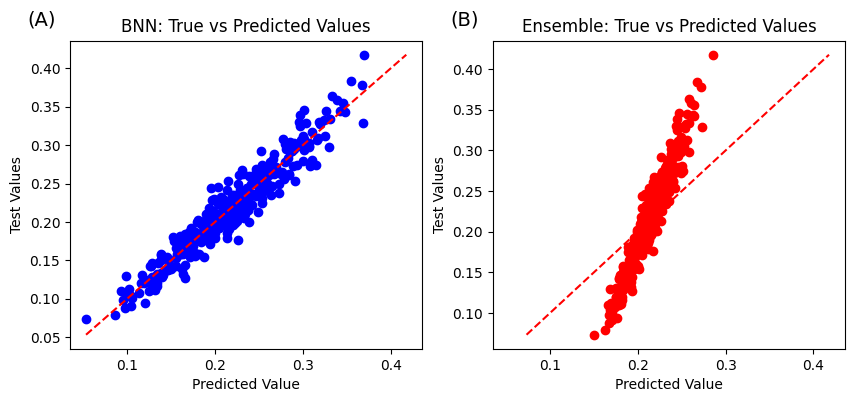

In [ ]:
#1 row, 2 plots
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharex = True)

#Scatterplot of actual values vs predictions (BNN)
axs[0].scatter(predictions_bnn, yTest, color='blue')
min_val = min(predictions_bnn.min(), yTest.min())
max_val = max(predictions_bnn.max(), yTest.max())
axs[0].plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')
axs[0].set_title('BNN: True vs Predicted Values')
axs[0].set_xlabel('Predicted Value')
axs[0].set_ylabel('Test Values')

#Scatterplot of actual values vs predictions (ensemble)
axs[1].scatter(meanof5List_ens, yTest, color='red')
min_val = min(meanof5List_ens.min(), yTest.min())
max_val = max(meanof5List_ens.max(), yTest.max())
axs[1].plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')
axs[1].set_title('Ensemble: True vs Predicted Values')
axs[1].set_xlabel('Predicted Value')
axs[1].set_ylabel('Test Values')

#For each sub-plot, add a letter in top left corner
for i, ax in enumerate(axs):
    # your plotting command here
    # ax.hist(data[i])

    ax.text(
        -0.12, 1.1,
        f'({letters[i]})',
        transform=ax.transAxes,
        fontsize=14,
        va='top'
    )
#Export image

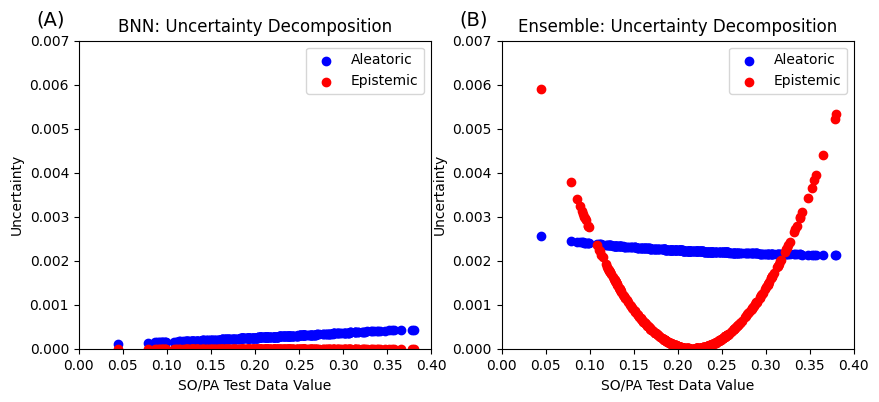

In [ ]:
#1 row, 2 plots
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

#Scatterplot of aleatoric and epistemic uncertainty vs test values (BNN)
axs[0].scatter(sopaTest, aleatoric_bnn, label='Aleatoric', color='blue')
axs[0].scatter(sopaTest, epistemic_bnn, label='Epistemic', color='red')
axs[0].set_title('BNN: Uncertainty Decomposition')
axs[0].set_xlabel('SO/PA Test Data Value')
axs[0].set_ylabel('Uncertainty')
axs[0].legend()
axs[0].set_xlim(0,0.4)
axs[0].set_ylim(0,0.007)

#Scatterplot of aleatoric and epistemic uncertainty vs test values (ensemble)
axs[1].scatter(sopaTest, aleatoric_ens, label='Aleatoric', color='blue')
axs[1].scatter(sopaTest, epistemic_ens, label='Epistemic', color='red')
axs[1].set_title('Ensemble: Uncertainty Decomposition')
axs[1].set_xlabel('SO/PA Test Data Value')
axs[1].set_ylabel('Uncertainty')
axs[1].legend()
axs[1].set_xlim(0,0.4)
axs[1].set_ylim(0,0.007)

#For each sub-plot, add a letter in top left corner
for i, ax in enumerate(axs):
    # your plotting command here
    # ax.hist(data[i])

    ax.text(
        -0.12, 1.1,
        f'({letters[i]})',
        transform=ax.transAxes,
        fontsize=14,
        va='top'
    )
#Export image

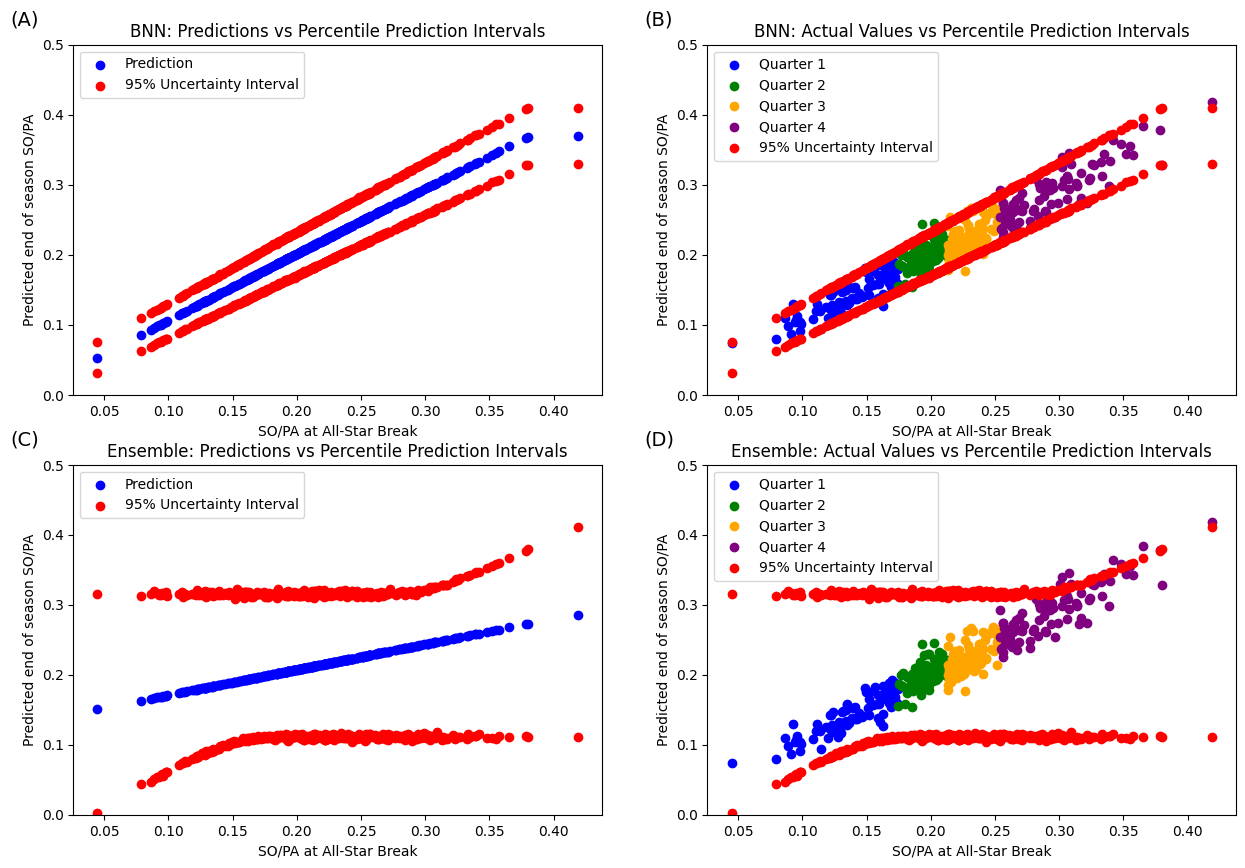

In [ ]:
#2 rows, 2 plots each
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

#Plot upper and lower bound of percentile intervals (BNN)
axs[0,0].scatter(sopaTest, predictions_bnn, label='Prediction', color='blue')
axs[0,0].scatter(sopaTest, phigh_bnn, color='red', label='95% Uncertainty Interval')
axs[0,0].scatter(sopaTest, plow_bnn, color='red')
axs[0,0].legend(loc = 'upper left')
axs[0,0].set_xlabel('SO/PA at All-Star Break')
axs[0,0].set_ylabel('Predicted end of season SO/PA')
axs[0,0].set_title('BNN: Predictions vs Percentile Prediction Intervals')
axs[0,0].set_ylim(0.00, 0.50)

#Plot upper and lower bound of percentile intervals, actual data color-coded by quarter (BNN)
axs[0,1].scatter(sopaTest[ix0], yTest[ix0], color='blue', label='Quarter 1')
axs[0,1].scatter(sopaTest[ix1], yTest[ix1], color='green', label='Quarter 2')
axs[0,1].scatter(sopaTest[ix2], yTest[ix2], color='orange', label='Quarter 3')
axs[0,1].scatter(sopaTest[ix3], yTest[ix3], color='purple', label='Quarter 4')
axs[0,1].scatter(sopaTest, phigh_bnn, color='red', label='95% Uncertainty Interval')
axs[0,1].scatter(sopaTest, plow_bnn, color='red')
axs[0,1].legend(loc = 'upper left')
axs[0,1].set_xlabel('SO/PA at All-Star Break')
axs[0,1].set_ylabel('Predicted end of season SO/PA')
axs[0,1].set_title('BNN: Actual Values vs Percentile Prediction Intervals')
axs[0,1].set_ylim(0.00, 0.50)

#Plot upper and lower bound of percentile intervals (ensemble)
axs[1,0].scatter(sopaTest, meanof5List_ens, label='Prediction', color='blue')
axs[1,0].scatter(sopaTest, phigh_ens, color='red', label='95% Uncertainty Interval')
axs[1,0].scatter(sopaTest, plow_ens, color='red')
axs[1,0].legend(loc = 'upper left')
axs[1,0].set_xlabel('SO/PA at All-Star Break')
axs[1,0].set_ylabel('Predicted end of season SO/PA')
axs[1,0].set_title('Ensemble: Predictions vs Percentile Prediction Intervals')
axs[1,0].set_ylim(0.00, 0.50)

#Plot upper and lower bound of percentile intervals, actual data color-coded by quarter (ensemble)
axs[1,1].scatter(sopaTest[ix0], yTest[ix0], color='blue', label='Quarter 1')
axs[1,1].scatter(sopaTest[ix1], yTest[ix1], color='green', label='Quarter 2')
axs[1,1].scatter(sopaTest[ix2], yTest[ix2], color='orange', label='Quarter 3')
axs[1,1].scatter(sopaTest[ix3], yTest[ix3], color='purple', label='Quarter 4')
axs[1,1].scatter(sopaTest, phigh_ens, color='red', label='95% Uncertainty Interval')
axs[1,1].scatter(sopaTest, plow_ens, color='red')
axs[1,1].legend(loc = 'upper left')
axs[1,1].set_xlabel('SO/PA at All-Star Break')
axs[1,1].set_ylabel('Predicted end of season SO/PA')
axs[1,1].set_title('Ensemble: Actual Values vs Percentile Prediction Intervals')
axs[1,1].set_ylim(0.00, 0.50)

#For each sub-plot, add a letter in top left corner
for i, ax in enumerate(np.ravel(axs)):   # ← flatten to 1D
    ax.text(
        -0.12, 1.10,
        f'({letters[i]})',
        transform=ax.transAxes,
        fontsize=14,
        va='top'
    )
#Export image

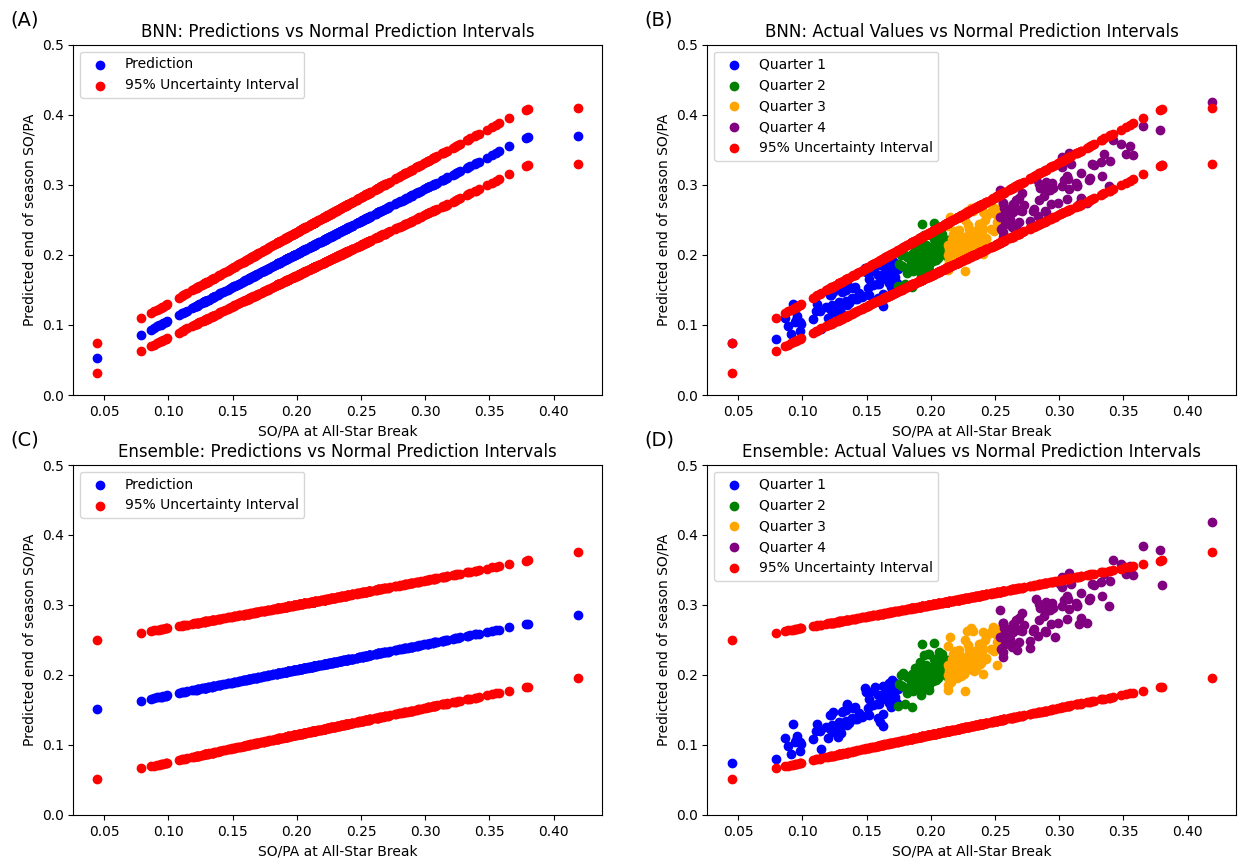

In [ ]:
#2 rows, 2 plots each
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

#Plot upper and lower bound of normal intervals (BNN)
axs[0,0].scatter(sopaTest, predictions_bnn, label='Prediction', color='blue')
axs[0,0].scatter(sopaTest, LBs_bnn, color='red', label='95% Uncertainty Interval')
axs[0,0].scatter(sopaTest, UBs_bnn, color='red')
axs[0,0].legend(loc = 'upper left')
axs[0,0].set_xlabel('SO/PA at All-Star Break')
axs[0,0].set_ylabel('Predicted end of season SO/PA')
axs[0,0].set_title('BNN: Predictions vs Normal Prediction Intervals')
axs[0,0].set_ylim(0.00, 0.50)

#Plot upper and lower bound of normal intervals, actual data color-coded by quarter (BNN)
axs[0,1].scatter(sopaTest[ix0], yTest[ix0], color='blue', label='Quarter 1')
axs[0,1].scatter(sopaTest[ix1], yTest[ix1], color='green', label='Quarter 2')
axs[0,1].scatter(sopaTest[ix2], yTest[ix2], color='orange', label='Quarter 3')
axs[0,1].scatter(sopaTest[ix3], yTest[ix3], color='purple', label='Quarter 4')
axs[0,1].scatter(sopaTest, LBs_bnn, color='red', label='95% Uncertainty Interval')
axs[0,1].scatter(sopaTest, UBs_bnn, color='red')
axs[0,1].legend(loc = 'upper left')
axs[0,1].set_xlabel('SO/PA at All-Star Break')
axs[0,1].set_ylabel('Predicted end of season SO/PA')
axs[0,1].set_title('BNN: Actual Values vs Normal Prediction Intervals')
axs[0,1].set_ylim(0.00, 0.50)

#Plot upper and lower bound of normal intervals (ensemble)
axs[1,0].scatter(sopaTest, meanof5List_ens, label='Prediction', color='blue')
axs[1,0].scatter(sopaTest, LBs_ens, color='red', label='95% Uncertainty Interval')
axs[1,0].scatter(sopaTest, UBs_ens, color='red')
axs[1,0].legend(loc = 'upper left')
axs[1,0].set_xlabel('SO/PA at All-Star Break')
axs[1,0].set_ylabel('Predicted end of season SO/PA')
axs[1,0].set_title('Ensemble: Predictions vs Normal Prediction Intervals')
axs[1,0].set_ylim(0.00, 0.50)

#Plot upper and lower bound of normal intervals, actual data color-coded by quarter (ensemble)
axs[1,1].scatter(sopaTest[ix0], yTest[ix0], color='blue', label='Quarter 1')
axs[1,1].scatter(sopaTest[ix1], yTest[ix1], color='green', label='Quarter 2')
axs[1,1].scatter(sopaTest[ix2], yTest[ix2], color='orange', label='Quarter 3')
axs[1,1].scatter(sopaTest[ix3], yTest[ix3], color='purple', label='Quarter 4')
axs[1,1].scatter(sopaTest, LBs_ens, color='red', label='95% Uncertainty Interval')
axs[1,1].scatter(sopaTest, UBs_ens, color='red')
axs[1,1].legend(loc = 'upper left')
axs[1,1].set_xlabel('SO/PA at All-Star Break')
axs[1,1].set_ylabel('Predicted end of season SO/PA')
axs[1,1].set_title('Ensemble: Actual Values vs Normal Prediction Intervals')
axs[1,1].set_ylim(0.00, 0.50)

#For each sub-plot, add a letter in top left corner
for i, ax in enumerate(np.ravel(axs)):   # ← flatten to 1D
    ax.text(
        -0.12, 1.10,
        f'({letters[i]})',
        transform=ax.transAxes,
        fontsize=14,
        va='top'
    )
#Export image

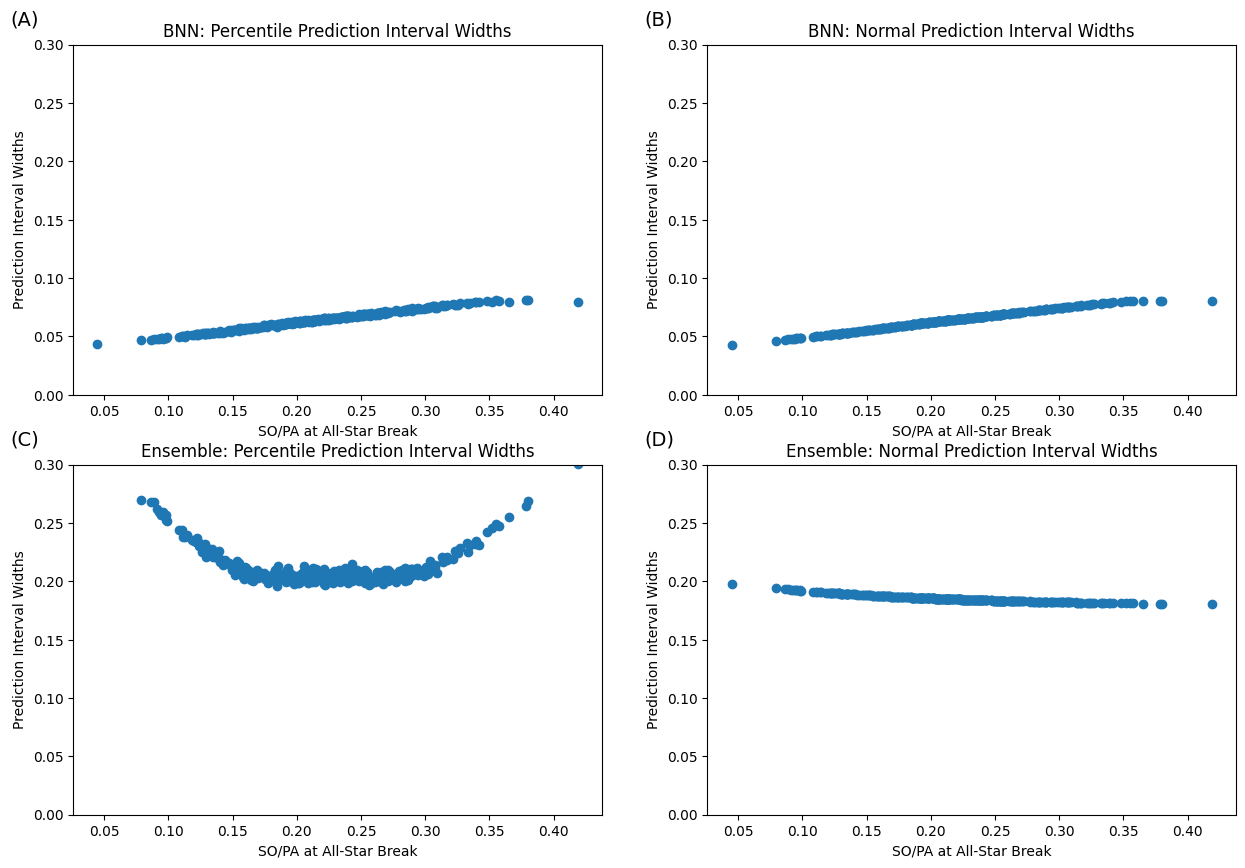

In [ ]:
#2 rows, 2 plots each
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

#Scatterplot of percentile interval widths vs actual values (BNN)
axs[0,0].scatter(sopaTest, widths_bnn)
axs[0,0].set_title('BNN: Percentile Prediction Interval Widths')
axs[0,0].set_xlabel('SO/PA at All-Star Break')
axs[0,0].set_ylabel('Prediction Interval Widths')
axs[0,0].set_ylim(0.000, 0.3)

#Scatterplot of normal interval widths vs actual values (BNN)
axs[0,1].scatter(sopaTest, listWidths_bnn)
axs[0,1].set_title('BNN: Normal Prediction Interval Widths')
axs[0,1].set_xlabel('SO/PA at All-Star Break')
axs[0,1].set_ylabel('Prediction Interval Widths')
axs[0,1].set_ylim(0.000, 0.3)

#Scatterplot of percentile interval widths vs actual values (ensemble)
axs[1,0].scatter(sopaTest, widths_ens)
axs[1,0].set_title('Ensemble: Percentile Prediction Interval Widths')
axs[1,0].set_xlabel('SO/PA at All-Star Break')
axs[1,0].set_ylabel('Prediction Interval Widths')
axs[1,0].set_ylim(0.000, 0.3)

#Scatterplot of normal interval widths vs actual values (ensemble)
axs[1,1].scatter(sopaTest, listWidths_ens)
axs[1,1].set_title('Ensemble: Normal Prediction Interval Widths')
axs[1,1].set_xlabel('SO/PA at All-Star Break')
axs[1,1].set_ylabel('Prediction Interval Widths')
axs[1,1].set_ylim(0.000, 0.3)

#For each sub-plot, add a letter in top left corner
for i, ax in enumerate(np.ravel(axs)):   # ← flatten to 1D
    ax.text(
        -0.12, 1.10,
        f'({letters[i]})',
        transform=ax.transAxes,
        fontsize=14,
        va='top'
    )
#Export image

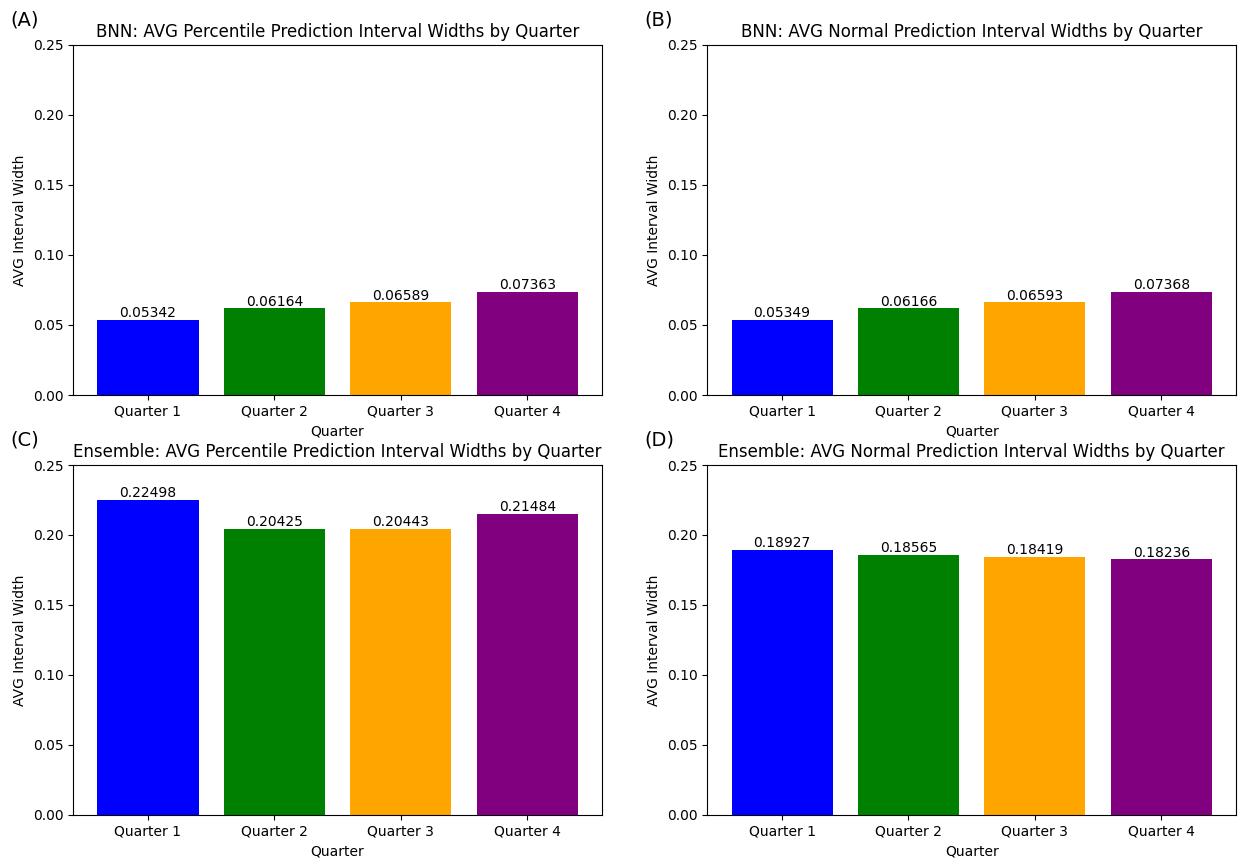

In [ ]:
#2 rows, 2 plots each
#AVG interval width by quarters
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

#Setting labels and colors of bars for each chart
colors = ['blue','green','orange','purple']
labels = ['Quarter 1', 'Quarter 2', 'Quarter 3', 'Quarter 4']

#Bar chart of widths of percentile intervals (BNN)
bars1 = axs[0,0].bar(labels, [np.mean(Q1_per_bnn_widths), np.mean(Q2_per_bnn_widths), np.mean(Q3_per_bnn_widths), np.mean(Q4_per_bnn_widths)], color = colors)
axs[0,0].bar_label(bars1,fmt='%.5f')
axs[0,0].set_title('BNN: AVG Percentile Prediction Interval Widths by Quarter')
axs[0,0].set_xlabel('Quarter')
axs[0,0].set_ylabel('AVG Interval Width')
axs[0,0].set_ylim(0.0, 0.25)

#Bar chart of widths of normal intervals (BNN)
bars2 = axs[0,1].bar(labels, [np.mean(Q1_st_bnn_widths), np.mean(Q2_st_bnn_widths), np.mean(Q3_st_bnn_widths), np.mean(Q4_st_bnn_widths)], color = colors)
axs[0,1].bar_label(bars2,fmt='%.5f')
axs[0,1].set_title('BNN: AVG Normal Prediction Interval Widths by Quarter')
axs[0,1].set_xlabel('Quarter')
axs[0,1].set_ylabel('AVG Interval Width')
axs[0,1].set_ylim(0.0, 0.25)

#Bar chart of widths of percentile intervals (ensemble)
bars3=axs[1,0].bar(labels, [np.mean(Q1_per_ens_widths), np.mean(Q2_per_ens_widths), np.mean(Q3_per_ens_widths), np.mean(Q4_per_ens_widths)], color = colors)
axs[1,0].bar_label(bars3,fmt='%.5f')
axs[1,0].set_title('Ensemble: AVG Percentile Prediction Interval Widths by Quarter')
axs[1,0].set_xlabel('Quarter')
axs[1,0].set_ylabel('AVG Interval Width')
axs[1,0].set_ylim(0.0, 0.25)

#Bar chart of widths of normal intervals (ensemble)
bars4=axs[1,1].bar(labels, [np.mean(Q1_st_ens_widths), np.mean(Q2_st_ens_widths), np.mean(Q3_st_ens_widths), np.mean(Q4_st_ens_widths)], color = colors)
axs[1,1].bar_label(bars4,fmt='%.5f')
axs[1,1].set_title('Ensemble: AVG Normal Prediction Interval Widths by Quarter')
axs[1,1].set_xlabel('Quarter')
axs[1,1].set_ylabel('AVG Interval Width')
axs[1,1].set_ylim(0.0, 0.25)

#For each sub-plot, add a letter in top left corner
for i, ax in enumerate(np.ravel(axs)):   # ← flatten to 1D
    ax.text(
        -0.12, 1.10,
        f'({letters[i]})',
        transform=ax.transAxes,
        fontsize=14,
        va='top'
    )
#Export image

In [ ]:
#QQ Plots - choosing players at varying SO/PA values
#Loop through to print value and index
for index, value in enumerate(sopaTest, start=0):
    print(index, value)

0 0.304
1 0.16605166051660517
2 0.20666666666666667
3 0.140625
4 0.2625
5 0.26865671641791045
6 0.09477124183006536
7 0.31382978723404253
8 0.25617283950617287
9 0.15137614678899083
10 0.26744186046511625
11 0.22635135135135134
12 0.11077844311377245
13 0.1969111969111969
14 0.15868263473053892
15 0.22965116279069767
16 0.2112676056338028
17 0.1671388101983003
18 0.32547169811320753
19 0.15806451612903225
20 0.13942307692307693
21 0.24025974025974026
22 0.23154362416107382
23 0.16470588235294117
24 0.23948220064724918
25 0.12972972972972974
26 0.19063545150501673
27 0.3076923076923077
28 0.29473684210526313
29 0.12121212121212122
30 0.18592964824120603
31 0.25471698113207547
32 0.18556701030927836
33 0.23783783783783785
34 0.12737127371273713
35 0.21351351351351353
36 0.3387096774193548
37 0.21447721179624665
38 0.2845528455284553
39 0.418848167539267
40 0.11139896373056994
41 0.1625615763546798
42 0.16109422492401215
43 0.12211981566820276
44 0.2217391304347826
45 0.26148409893992935


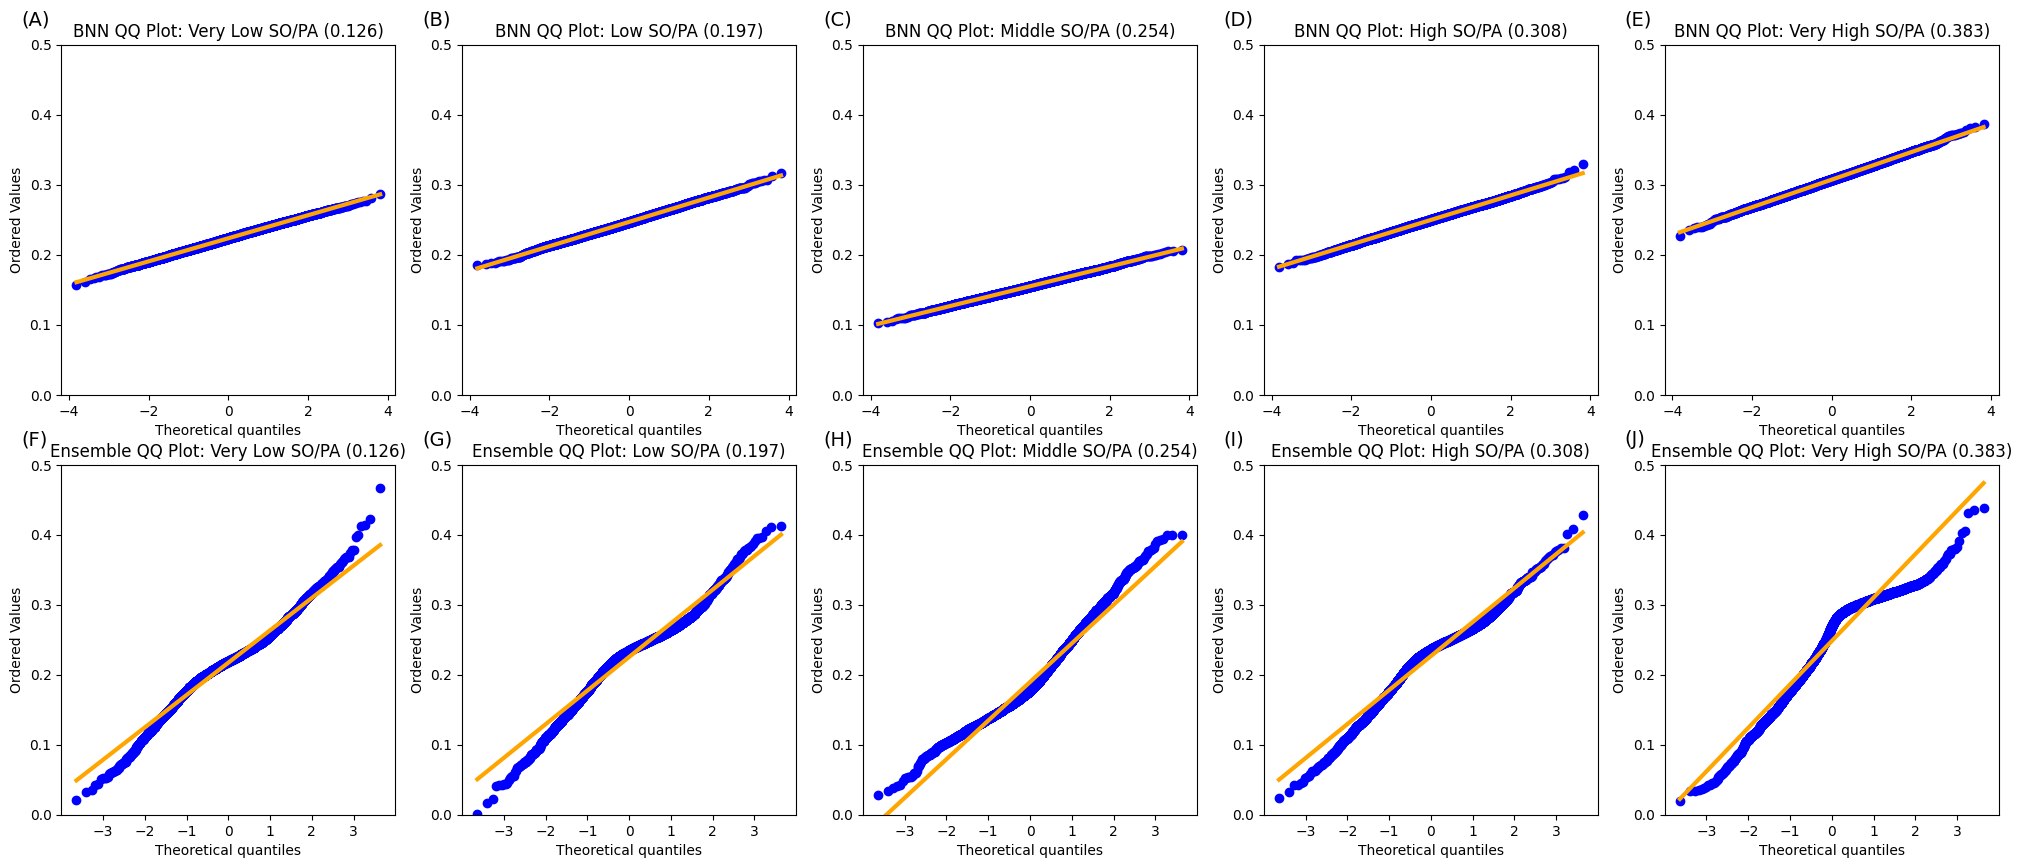

In [ ]:
#QQ plots
#Selected players at varying SO/PA levels
#Very low - 0.126 index: 147
#Low - 0.197, index: 114
#Middle - 0.254, index: 137
#High - 0.308, index: 180
#Very High - 0.383 index: 7

#2 rows, 5 plots each
fig, axs = plt.subplots(2, 5, figsize=(25, 10))

#For each player, plot a QQ plot to test normality for both the BNN and ensemble distributions of samples
#Very low player
stats.probplot(samples_bnn[:,147], dist="norm", plot=axs[0,0])
axs[0,0].get_lines()[1].set_linewidth(3)
axs[0,0].get_lines()[1].set_color('orange')
axs[0,0].set_title('BNN QQ Plot: Very Low SO/PA (0.126)')
axs[0,0].set_ylim(0.0, 0.50)
stats.probplot(samples_ens[:,147], dist="norm", plot=axs[1,0])
axs[1,0].get_lines()[1].set_linewidth(3)
axs[1,0].get_lines()[1].set_color('orange')
axs[1,0].set_title('Ensemble QQ Plot: Very Low SO/PA (0.126)')
axs[1,0].set_ylim(0.0, 0.50)
#Low player
stats.probplot(samples_bnn[:,114], dist="norm", plot=axs[0,1])
axs[0,1].get_lines()[1].set_linewidth(3)
axs[0,1].get_lines()[1].set_color('orange')
axs[0, 1].set_title('BNN QQ Plot: Low SO/PA (0.197)')
axs[0,1].set_ylim(0.0, 0.50)
stats.probplot(samples_ens[:,114], dist="norm", plot=axs[1,1])
axs[1,1].get_lines()[1].set_linewidth(3)
axs[1,1].get_lines()[1].set_color('orange')
axs[1,1].set_title('Ensemble QQ Plot: Low SO/PA (0.197)')
axs[1,1].set_ylim(0.0, 0.50)
#Middle player
stats.probplot(samples_bnn[:,137], dist="norm", plot=axs[0,2])
axs[0,2].get_lines()[1].set_linewidth(3)
axs[0,2].get_lines()[1].set_color('orange')
axs[0,2].set_title('BNN QQ Plot: Middle SO/PA (0.254)')
axs[0,2].set_ylim(0.0, 0.50)
stats.probplot(samples_ens[:,137], dist="norm", plot=axs[1,2])
axs[1,2].get_lines()[1].set_linewidth(3)
axs[1,2].get_lines()[1].set_color('orange')
axs[1,2].set_title('Ensemble QQ Plot: Middle SO/PA (0.254)')
axs[1,2].set_ylim(0.0, 0.50)
#High player
stats.probplot(samples_bnn[:,180], dist="norm", plot=axs[0,3])
axs[0,3].get_lines()[1].set_linewidth(3)
axs[0,3].get_lines()[1].set_color('orange')
axs[0,3].set_ylim(0.0, 0.50)
axs[0, 3].set_title('BNN QQ Plot: High SO/PA (0.308)')
stats.probplot(samples_ens[:,180], dist="norm", plot=axs[1,3])
axs[1,3].get_lines()[1].set_linewidth(3)
axs[1,3].get_lines()[1].set_color('orange')
axs[1,3].set_title('Ensemble QQ Plot: High SO/PA (0.308)')
axs[1,3].set_ylim(0.0, 0.50)
#Very high player
stats.probplot(samples_bnn[:,7], dist="norm", plot=axs[0,4])
axs[0,4].get_lines()[1].set_linewidth(3)
axs[0,4].get_lines()[1].set_color('orange')
axs[0, 4].set_title('BNN QQ Plot: Very High SO/PA (0.383)')
axs[0,4].set_ylim(0.0, 0.50)
stats.probplot(samples_ens[:,7], dist="norm", plot=axs[1,4])
axs[1,4].get_lines()[1].set_linewidth(3)
axs[1,4].get_lines()[1].set_color('orange')
axs[1,4].set_title('Ensemble QQ Plot: Very High SO/PA (0.383)')
axs[1,4].set_ylim(0.0, 0.50)

#For each sub-plot, add a letter in top left corner
for i, ax in enumerate(np.ravel(axs)):   # ← flatten to 1D
    ax.text(
        -0.12, 1.10,
        f'({letters[i]})',
        transform=ax.transAxes,
        fontsize=14,
        va='top'
    )
#Export image

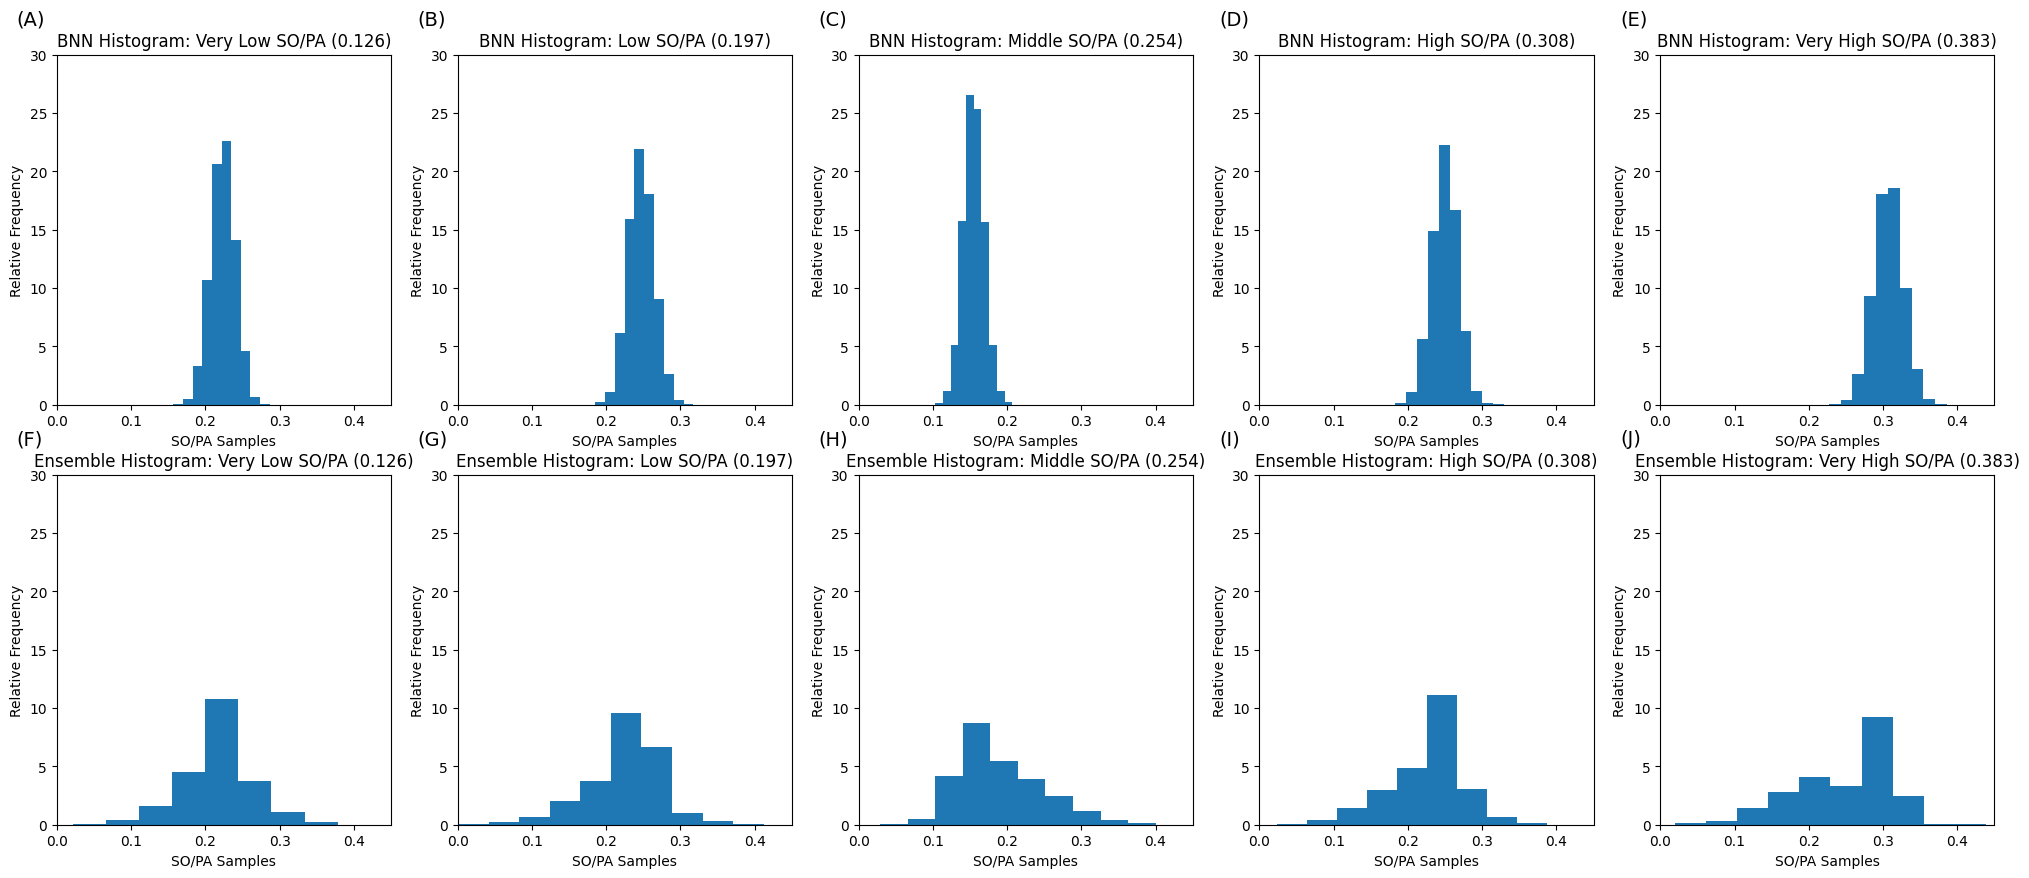

In [ ]:
#Histograms
#Very low - 0.126 index: 147
#Low - 0.197, index: 114
#Middle - 0.254, index: 137
#High - 0.308, index: 180
#Very High - 0.383 index: 7

#2 rows, 5 plots each
fig, axs = plt.subplots(2, 5, figsize=(25, 10))

#For each player, plot a histogram to test normality for both the BNN and ensemble distributions of samples
#Very low player
axs[0,0].hist(samples_bnn[:,147], density = True)
axs[0, 0].set_title('BNN Histogram: Very Low SO/PA (0.126)')
axs[0,0].set_xlabel("SO/PA Samples")
axs[0,0].set_ylabel("Relative Frequency")
axs[0,0].set_xlim(0.0, 0.45)
axs[0,0].set_ylim(0, 30)
axs[1,0].hist(samples_ens[:,147], density = True)
axs[1,0].set_title('Ensemble Histogram: Very Low SO/PA (0.126)')
axs[1,0].set_xlabel("SO/PA Samples")
axs[1,0].set_ylabel("Relative Frequency")
axs[1,0].set_xlim(0.0, 0.45)
axs[1,0].set_ylim(0, 30)
#Low player
axs[0,1].hist(samples_bnn[:,114],  density = True)
axs[0, 1].set_title('BNN Histogram: Low SO/PA (0.197)')
axs[0,1].set_xlabel("SO/PA Samples")
axs[0,1].set_ylabel("Relative Frequency")
axs[0,1].set_xlim(0.0, 0.45)
axs[0,1].set_ylim(0, 30)
axs[1,1].hist(samples_ens[:,114],  density = True)
axs[1,1].set_title('Ensemble Histogram: Low SO/PA (0.197)')
axs[1,1].set_xlabel("SO/PA Samples")
axs[1,1].set_ylabel("Relative Frequency")
axs[1,1].set_xlim(0.0, 0.45)
axs[1,1].set_ylim(0, 30)
#Middle player
axs[0,2].hist(samples_bnn[:,137],  density = True)
axs[0, 2].set_title('BNN Histogram: Middle SO/PA (0.254)')
axs[0,2].set_xlabel("SO/PA Samples")
axs[0,2].set_ylabel("Relative Frequency")
axs[0,2].set_xlim(0.0, 0.45)
axs[0,2].set_ylim(0, 30)
axs[1,2].hist(samples_ens[:,137],  density = True)
axs[1,2].set_title('Ensemble Histogram: Middle SO/PA (0.254)')
axs[1,2].set_xlabel("SO/PA Samples")
axs[1,2].set_ylabel("Relative Frequency")
axs[1,2].set_xlim(0.0, 0.45)
axs[1,2].set_ylim(0, 30)
#High player
axs[0,3].hist(samples_bnn[:,180],  density = True)
axs[0, 3].set_title('BNN Histogram: High SO/PA (0.308)')
axs[0,3].set_xlabel("SO/PA Samples")
axs[0,3].set_ylabel("Relative Frequency")
axs[0,3].set_xlim(0.0, 0.45)
axs[0,3].set_ylim(0, 30)
axs[1,3].hist(samples_ens[:,180],  density = True)
axs[1,3].set_title('Ensemble Histogram: High SO/PA (0.308)')
axs[1,3].set_xlabel("SO/PA Samples")
axs[1,3].set_ylabel("Relative Frequency")
axs[1,3].set_xlim(0.0, 0.45)
axs[1,3].set_ylim(0, 30)
#Very high player
axs[0,4].hist(samples_bnn[:,7],  density = True)
axs[0, 4].set_title('BNN Histogram: Very High SO/PA (0.383)')
axs[0,4].set_xlabel("SO/PA Samples")
axs[0,4].set_ylabel("Relative Frequency")
axs[0,4].set_xlim(0.0, 0.45)
axs[0,4].set_ylim(0, 30)
axs[1,4].hist(samples_ens[:,7],  density = True)
axs[1,4].set_title('Ensemble Histogram: Very High SO/PA (0.383)')
axs[1,4].set_xlabel("SO/PA Samples")
axs[1,4].set_ylabel("Relative Frequency")
axs[1,4].set_xlim(0.0, 0.45)
axs[1,4].set_ylim(0, 30)

#For each sub-plot, add a letter in top left corner
for i, ax in enumerate(np.ravel(axs)):   # ← flatten to 1D
    ax.text(
        -0.12, 1.13,
        f'({letters[i]})',
        transform=ax.transAxes,
        fontsize=14,
        va='top'
    )
#Export image